# Feature Class Naturalness Check

This notebook tests whether the rule-based feature classes occupy natural structure in the 6-D metric space used by the node-grouping decision tree.

It consumes `output/research/feature_manifest.csv`, which is built from existing `node_grouping.csv` files by `scripts/research/build_feature_manifest.py`.

The analysis is intentionally dependency-light: it uses the Python standard library so it remains executable in this environment. If pandas / sklearn are available later, the same manifest can be reused for richer plots.

## Inline Summary Figure

The generated summary figure is embedded here so the notebook shows visual output immediately, even before running any cells.

![Feature class naturalness summary](feature_classes_naturalness.png)

The cells below generate proper notebook-native charts: marginal distributions, PCA/t-SNE scatter plots, per-dataset facets, clustering metric curves, confusion matrices, and threshold-sensitivity bars.

In [14]:
from pathlib import Path
import csv
import json
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = Path("<repo>")

sys.path.insert(0, str(REPO_ROOT))

from scripts.research import feature_clustering_analysis as fca

MANIFEST = REPO_ROOT / "output" / "research" / "feature_manifest.csv"
RESULTS_JSON = REPO_ROOT / "output" / "research" / "feature_clustering_results.json"
SUMMARY_PNG = REPO_ROOT / "output" / "research" / "feature_classes_naturalness.png"

rows = fca.load_rows(MANIFEST)
df_all = rows
df_dedup = fca.dedupe(rows)

len(df_all), len(df_dedup)

(27817, 8314)

## View A - Marginal Densities and Cut Thresholds

The runner computes the threshold-derived manifest and writes a summary figure. The first panel in `feature_classes_naturalness.png` contains the four cut metrics used directly by the tree: `peak_consistency_main`, `func_vs_sem_pct`, `sparsity_median`, and `layer`.

In [15]:
# Regenerate all analysis artefacts from the manifest.
# This uses deterministic samples for the expensive pure-Python clustering grid.
fca.main()

with RESULTS_JSON.open(encoding="utf-8") as handle:
    results = json.load(handle)

results["n_all_rows"], results["n_deduped"], results["class_counts_all"]

Loaded 27817 rows and 8314 deduped features
Finished all-row clustering
Finished deduped clustering
Finished book_characters_authors_batch
Finished paintings_painters_batch
Finished products_founders_batch
Finished sounds_colors_batch
Finished usa_states_batch
{
  "n_all_rows": 27817,
  "n_deduped": 8314,
  "class_counts_all": {
    "Semantic (Dictionary fallback)": 6264,
    "Semantic (Dictionary)": 7578,
    "Relationship": 5615,
    "Semantic (Concept)": 3476,
    "Ambiguous/Review": 786,
    "Say \"X\"": 4098
  },
  "class_counts_deduped": {
    "Semantic (Dictionary fallback)": 2175,
    "Semantic (Dictionary)": 3146,
    "Relationship": 811,
    "Semantic (Concept)": 1000,
    "Ambiguous/Review": 136,
    "Say \"X\"": 1046
  },
  "clustering": [
    {
      "frame": "all_rows",
      "algorithm": "kmeans",
      "k": 3,
      "n_clustered": 5000,
      "ari": 0.3229343178858348,
      "nmi": 0.4033068496401858,
      "silhouette": 0.5157395202686456
    },
    {
      "frame": "a

(27817,
 8314,
 {'Semantic (Dictionary fallback)': 6264,
  'Semantic (Dictionary)': 7578,
  'Relationship': 5615,
  'Semantic (Concept)': 3476,
  'Ambiguous/Review': 786,
  'Say "X"': 4098})

## View B - 2-D Projection Coloured by Hand Label

The dependency-free runner uses PCA(2). The original plan also requested t-SNE; this environment does not have sklearn installed, so t-SNE is left as an optional extension on the same standardized matrix. The summary figure includes the PCA scatter coloured by the rule label.

In [16]:
# Optional sklearn t-SNE projection, if sklearn is available in a richer environment.
try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    import numpy as np

    sample = fca.sample_rows(df_dedup, 5000)
    X = np.array([[row[key] for key in fca.FEATURES] for row in sample])
    X = StandardScaler().fit_transform(X)
    tsne_xy = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=0).fit_transform(X)
    print(tsne_xy.shape)
except Exception as exc:
    print(f"t-SNE skipped: {exc}")

(5000, 2)


## View C - Unsupervised Clustering vs. Hand Label

KMeans and diagonal-GMM are run for `k = 3, 4, 5, 6` on both all rows and deduped rows. The expensive clustering grid uses a deterministic 5,000-row sample when a frame is larger than that; manifest counts and sensitivity are computed on all rows.

In [17]:
def show_table(items, columns):
    print(" | ".join(columns))
    print(" | ".join(["---"] * len(columns)))
    for item in items:
        print(" | ".join(str(round(item[col], 4)) if isinstance(item[col], float) else str(item[col]) for col in columns))

show_table(
    results["clustering"],
    ["frame", "algorithm", "k", "n_clustered", "ari", "nmi", "silhouette"],
)

frame | algorithm | k | n_clustered | ari | nmi | silhouette
--- | --- | --- | --- | --- | --- | ---
all_rows | kmeans | 3 | 5000 | 0.3229 | 0.4033 | 0.5157
all_rows | kmeans | 4 | 5000 | 0.427 | 0.5222 | 0.4573
all_rows | kmeans | 5 | 5000 | 0.4668 | 0.5358 | 0.4609
all_rows | kmeans | 6 | 5000 | 0.4833 | 0.5576 | 0.4673
all_rows | gmm | 3 | 5000 | 0.3167 | 0.3957 | 0.5088
all_rows | gmm | 4 | 5000 | 0.42 | 0.5319 | 0.4463
all_rows | gmm | 5 | 5000 | 0.4179 | 0.5297 | 0.4023
all_rows | gmm | 6 | 5000 | 0.5082 | 0.5899 | 0.4228
deduped | kmeans | 3 | 5000 | 0.4462 | 0.447 | 0.5576
deduped | kmeans | 4 | 5000 | 0.5125 | 0.4919 | 0.5382
deduped | kmeans | 5 | 5000 | 0.5653 | 0.5697 | 0.6085
deduped | kmeans | 6 | 5000 | 0.5867 | 0.6026 | 0.67
deduped | gmm | 3 | 5000 | 0.4388 | 0.4413 | 0.5444
deduped | gmm | 4 | 5000 | 0.5056 | 0.4902 | 0.5226
deduped | gmm | 5 | 5000 | 0.5555 | 0.5668 | 0.597
deduped | gmm | 6 | 5000 | 0.5968 | 0.6126 | 0.6392


## View D - Threshold Sensitivity

Each primary threshold is perturbed by +/-10%. The `near_boundary` row reports the fraction of features close to the cut (`0.05` for unit-scale metrics, `5.0` percentage points for `func_vs_sem_pct`, `0.5` layers for `layer`).

In [18]:
show_table(
    results["sensitivity"],
    ["threshold", "perturbation", "flip_rate"],
)

threshold | perturbation | flip_rate
--- | --- | ---
dict | minus_10pct | 0.0152
dict | plus_10pct | 0.0149
dict | near_boundary | 0.0151
func | minus_10pct | 0.0005
func | plus_10pct | 0.0031
func | near_boundary | 0.0058
sparsity | minus_10pct | 0.0005
sparsity | plus_10pct | 0.0019
sparsity | near_boundary | 0.0029
layer | minus_10pct | 0.0
layer | plus_10pct | 0.0114
layer | near_boundary | 0.0362


## View E - Per-Dataset Transferability

KMeans and diagonal-GMM are rerun at `k=4` within each dataset. This checks whether the hand-tuned rule geometry transfers across domains or is mostly a USA-specific fit.

In [19]:
show_table(
    results["per_dataset"],
    ["dataset", "algorithm", "k", "n_clustered", "ari", "nmi", "silhouette"],
)

print(f"Summary figure: {SUMMARY_PNG}")

dataset | algorithm | k | n_clustered | ari | nmi | silhouette
--- | --- | --- | --- | --- | --- | ---
book_characters_authors_batch | kmeans | 4 | 5000 | 0.4964 | 0.529 | 0.4991
book_characters_authors_batch | gmm | 4 | 5000 | 0.5094 | 0.5409 | 0.4856
paintings_painters_batch | kmeans | 4 | 4390 | 0.2351 | 0.3585 | 0.4749
paintings_painters_batch | gmm | 4 | 4390 | 0.2468 | 0.3793 | 0.452
products_founders_batch | kmeans | 4 | 3250 | 0.5994 | 0.5635 | 0.5826
products_founders_batch | gmm | 4 | 3250 | 0.6226 | 0.6389 | 0.5395
sounds_colors_batch | kmeans | 4 | 2181 | 0.486 | 0.5323 | 0.5439
sounds_colors_batch | gmm | 4 | 2181 | 0.3926 | 0.4887 | 0.4446
usa_states_batch | kmeans | 4 | 5000 | 0.3492 | 0.4637 | 0.5095
usa_states_batch | gmm | 4 | 5000 | 0.3523 | 0.487 | 0.4565
Summary figure: <repo>/output/research/feature_classes_naturalness.png


# Proper Matplotlib / Seaborn Charts

These cells use the plotting stack already listed in `requirements.txt` (`pandas`, `matplotlib`, `seaborn`, `scikit-learn`). They are the publication-quality notebook views; the dependency-light runner above is only there so the analysis can still execute in a bare Python environment.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    confusion_matrix,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

METRIC_COLUMNS = [
    "peak_consistency_main",
    "n_distinct_peaks_log1p",
    "func_vs_sem_pct",
    "conf_F",
    "sparsity_median",
    "layer",
]

RAW_METRIC_COLUMNS = [
    "peak_consistency_main",
    "n_distinct_peaks",
    "func_vs_sem_pct",
    "conf_F",
    "sparsity_median",
    "layer",
]

CLASS_ORDER = [
    "Semantic (Dictionary)",
    "Semantic (Dictionary fallback)",
    "Semantic (Concept)",
    "Relationship",
    'Say "X"',
    "Ambiguous/Review",
]

PALETTE = dict(zip(CLASS_ORDER, sns.color_palette("tab10", n_colors=len(CLASS_ORDER))))

manifest = pd.read_csv(MANIFEST)
manifest["n_distinct_peaks_log1p"] = np.log1p(manifest["n_distinct_peaks"])


def class_label(row):
    if bool(row.get("review", False)):
        return "Ambiguous/Review"
    if row["pred_label"] == 'Say "X"':
        return 'Say "X"'
    if row["pred_label"] == "Relationship":
        return "Relationship"
    if row["subtype"] == "Dictionary":
        return "Semantic (Dictionary)"
    if row["subtype"] == "Dictionary (fallback)":
        return "Semantic (Dictionary fallback)"
    return "Semantic (Concept)"

manifest["class"] = manifest.apply(class_label, axis=1)

# One row per global CLT feature. This removes USA over-weighting and lets each physical feature vote once.
dedup = (
    manifest
    .groupby(["layer", "feature"], as_index=False)
    .agg({
        "dataset": lambda s: s.mode().iat[0],
        "class": lambda s: s.mode().iat[0],
        "peak_consistency_main": "median",
        "n_distinct_peaks": "median",
        "func_vs_sem_pct": "median",
        "conf_F": "median",
        "sparsity_median": "median",
    })
)
dedup["n_distinct_peaks_log1p"] = np.log1p(dedup["n_distinct_peaks"])

print(f"All rows: {len(manifest):,}")
print(f"Deduped global features: {len(dedup):,}")
dedup["class"].value_counts().reindex(CLASS_ORDER).dropna()

All rows: 27,817
Deduped global features: 8,314


class
Semantic (Dictionary)             3033
Semantic (Dictionary fallback)    2231
Semantic (Concept)                 991
Relationship                       867
Say "X"                           1039
Ambiguous/Review                   153
Name: count, dtype: int64

## Marginal Distributions With Decision Thresholds

These plots answer the first question directly: do the hand-set thresholds sit in valleys between populations, or do they slice through smooth distributions?

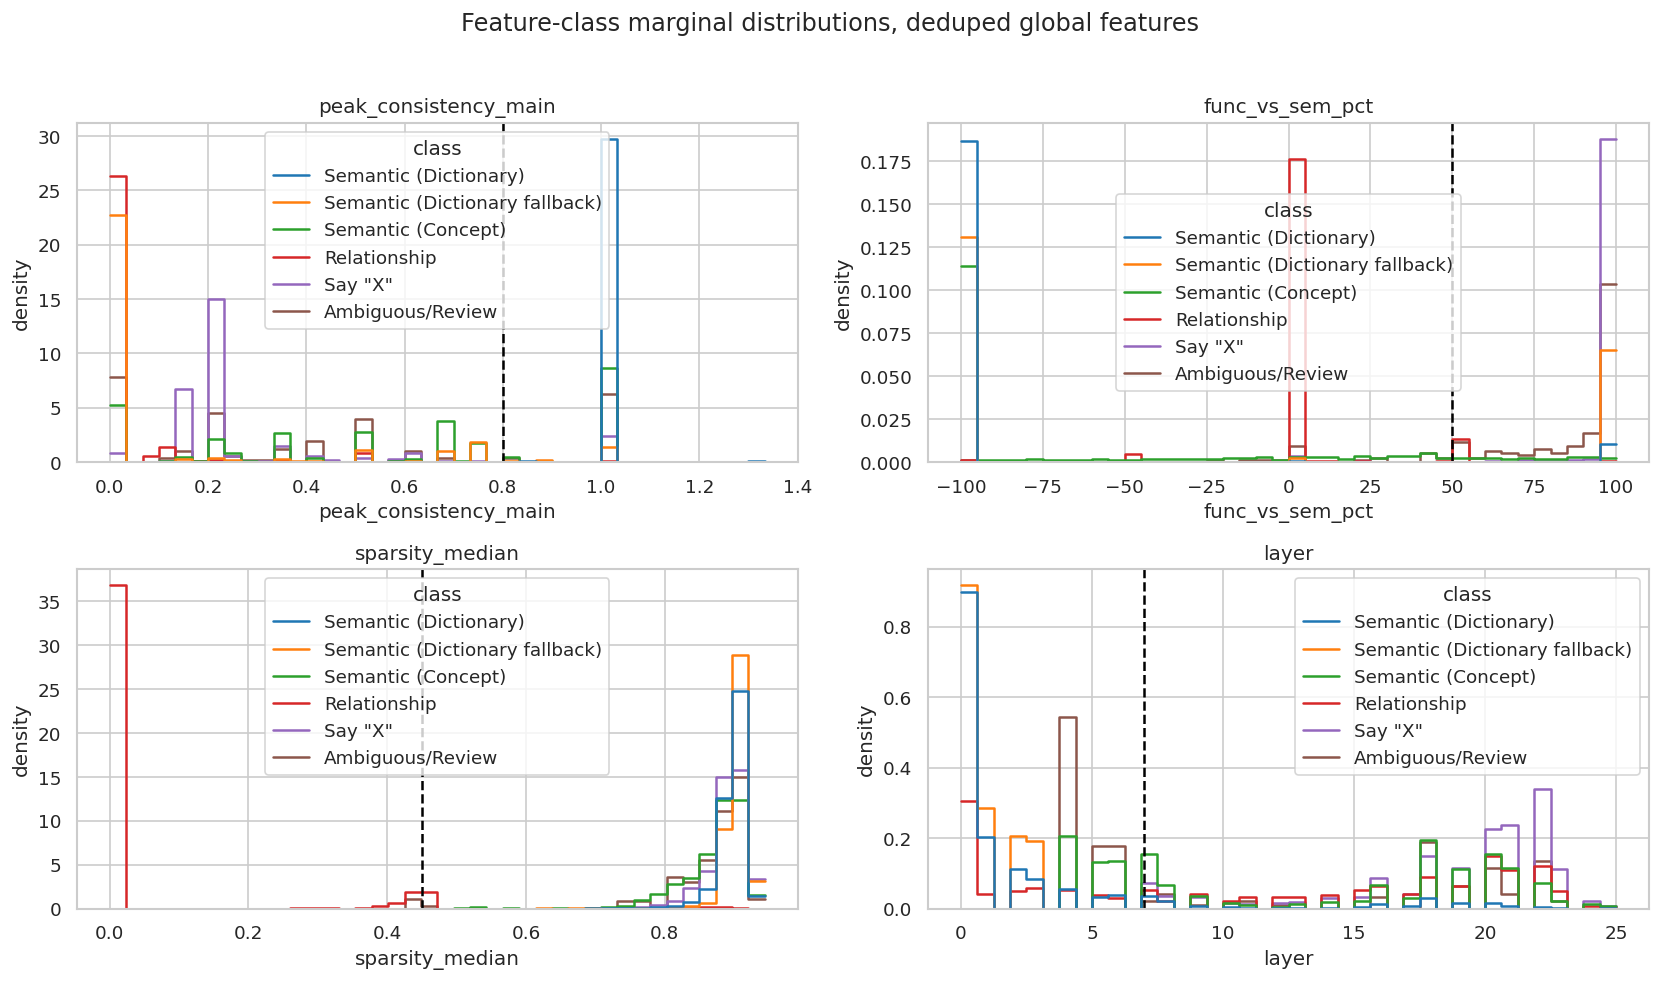

In [21]:
cut_metrics = [
    ("peak_consistency_main", 0.80, "Dictionary threshold"),
    ("func_vs_sem_pct", 50.0, "Say-X / Semantic threshold"),
    ("sparsity_median", 0.45, "Relationship threshold"),
    ("layer", 7.0, "Say-X layer threshold"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (metric, threshold, threshold_label) in zip(axes.flat, cut_metrics):
    sns.histplot(
        data=dedup,
        x=metric,
        hue="class",
        hue_order=CLASS_ORDER,
        palette=PALETTE,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        bins=40,
        ax=ax,
    )
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=threshold_label)
    ax.set_title(metric)
    ax.set_ylabel("density")
    ax.legend_.set_title("class") if ax.legend_ else None

fig.suptitle("Feature-class marginal distributions, deduped global features", y=1.02)
fig.tight_layout()
plt.show()

## PCA Scatter Plot

PCA is run on the standardized 6-D metric vector. `n_distinct_peaks` is log-transformed before standardization, matching the planned preprocessing.

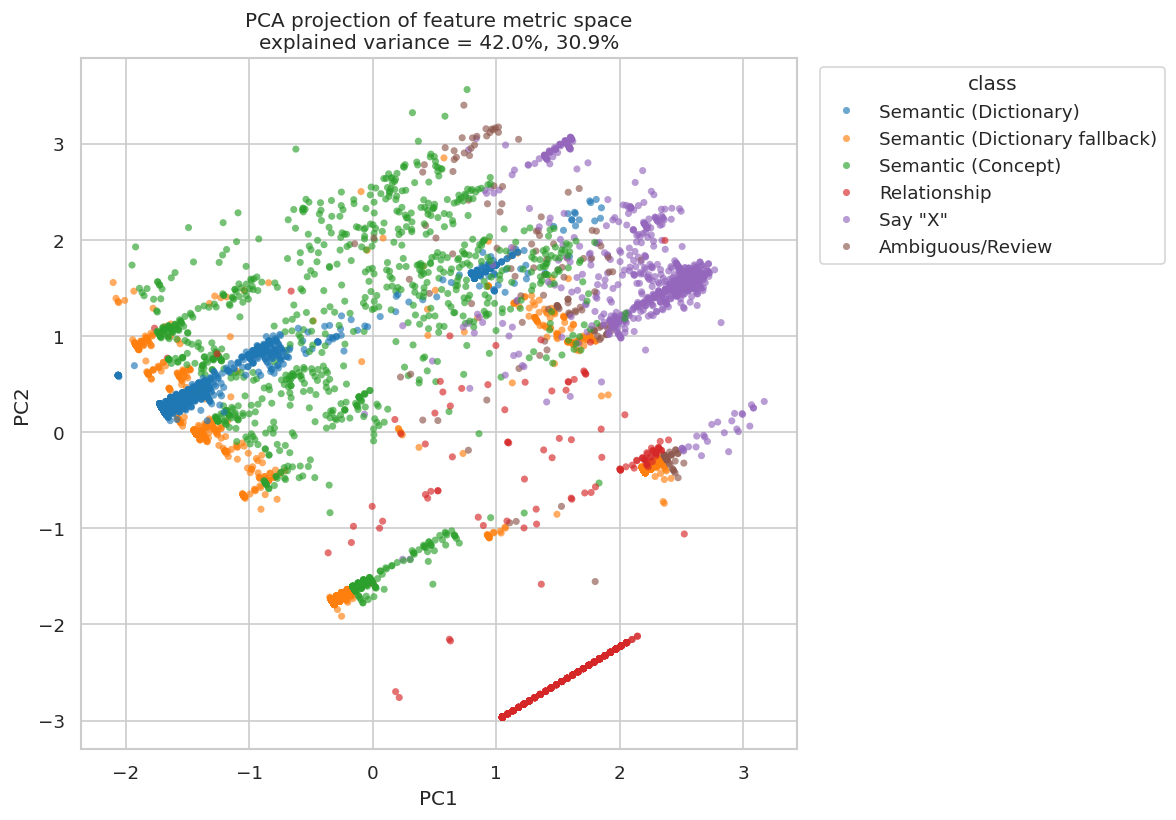

In [22]:
X = StandardScaler().fit_transform(dedup[METRIC_COLUMNS])
pca = PCA(n_components=2, random_state=0)
pca_xy = pca.fit_transform(X)

plot_df = dedup.copy()
plot_df["PC1"] = pca_xy[:, 0]
plot_df["PC2"] = pca_xy[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="class",
    hue_order=CLASS_ORDER,
    palette=PALETTE,
    s=18,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)
ax.set_title(
    "PCA projection of feature metric space\n"
    f"explained variance = {pca.explained_variance_ratio_[0]:.1%}, {pca.explained_variance_ratio_[1]:.1%}"
)
ax.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## t-SNE Scatter Plot

This is slower than PCA, so it uses a deterministic sample when the deduped frame is large. It is useful as a nonlinear visual check, not as statistical evidence by itself.

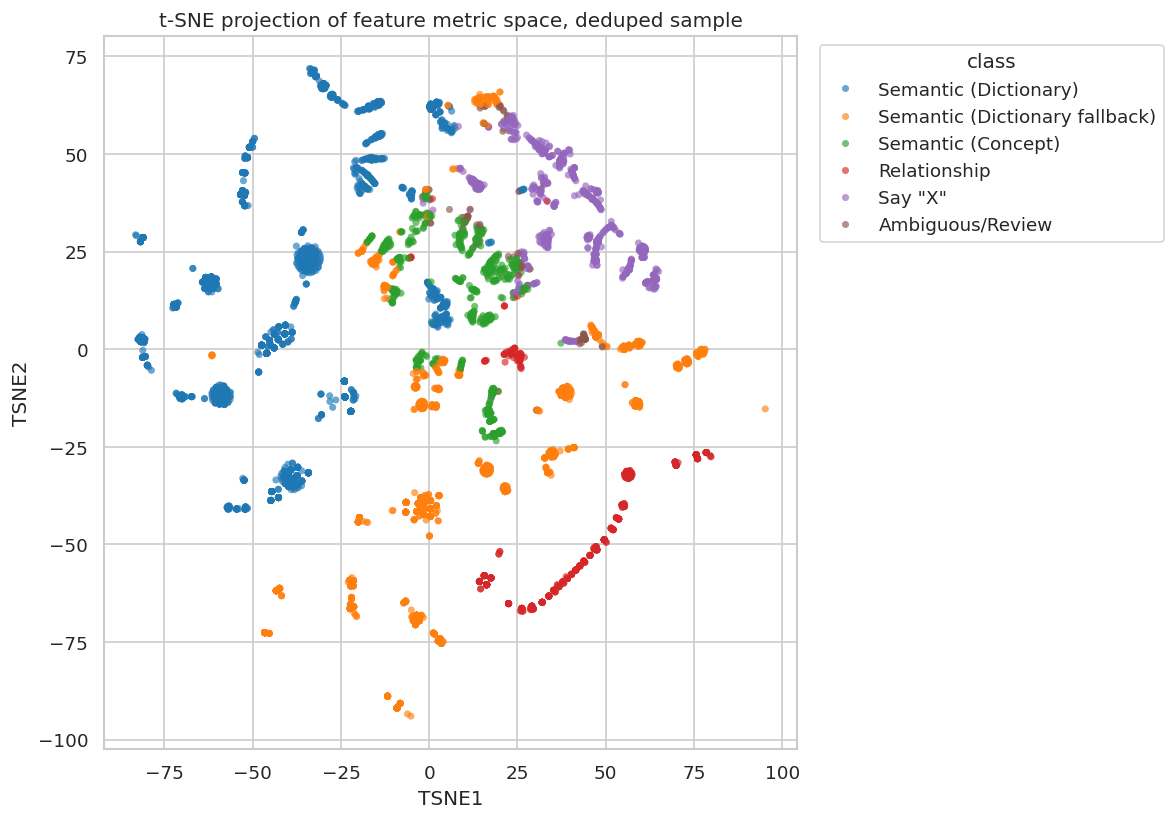

In [23]:
tsne_df = dedup.sample(n=min(5000, len(dedup)), random_state=0).copy()
X_tsne = StandardScaler().fit_transform(tsne_df[METRIC_COLUMNS])
tsne_xy = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=40,
    random_state=0,
).fit_transform(X_tsne)
tsne_df["TSNE1"] = tsne_xy[:, 0]
tsne_df["TSNE2"] = tsne_xy[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="class",
    hue_order=CLASS_ORDER,
    palette=PALETTE,
    s=18,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)
ax.set_title("t-SNE projection of feature metric space, deduped sample")
ax.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## Per-Dataset PCA Facets

This checks whether the same class regions are reused across domains, or whether the apparent clusters are domain-specific.

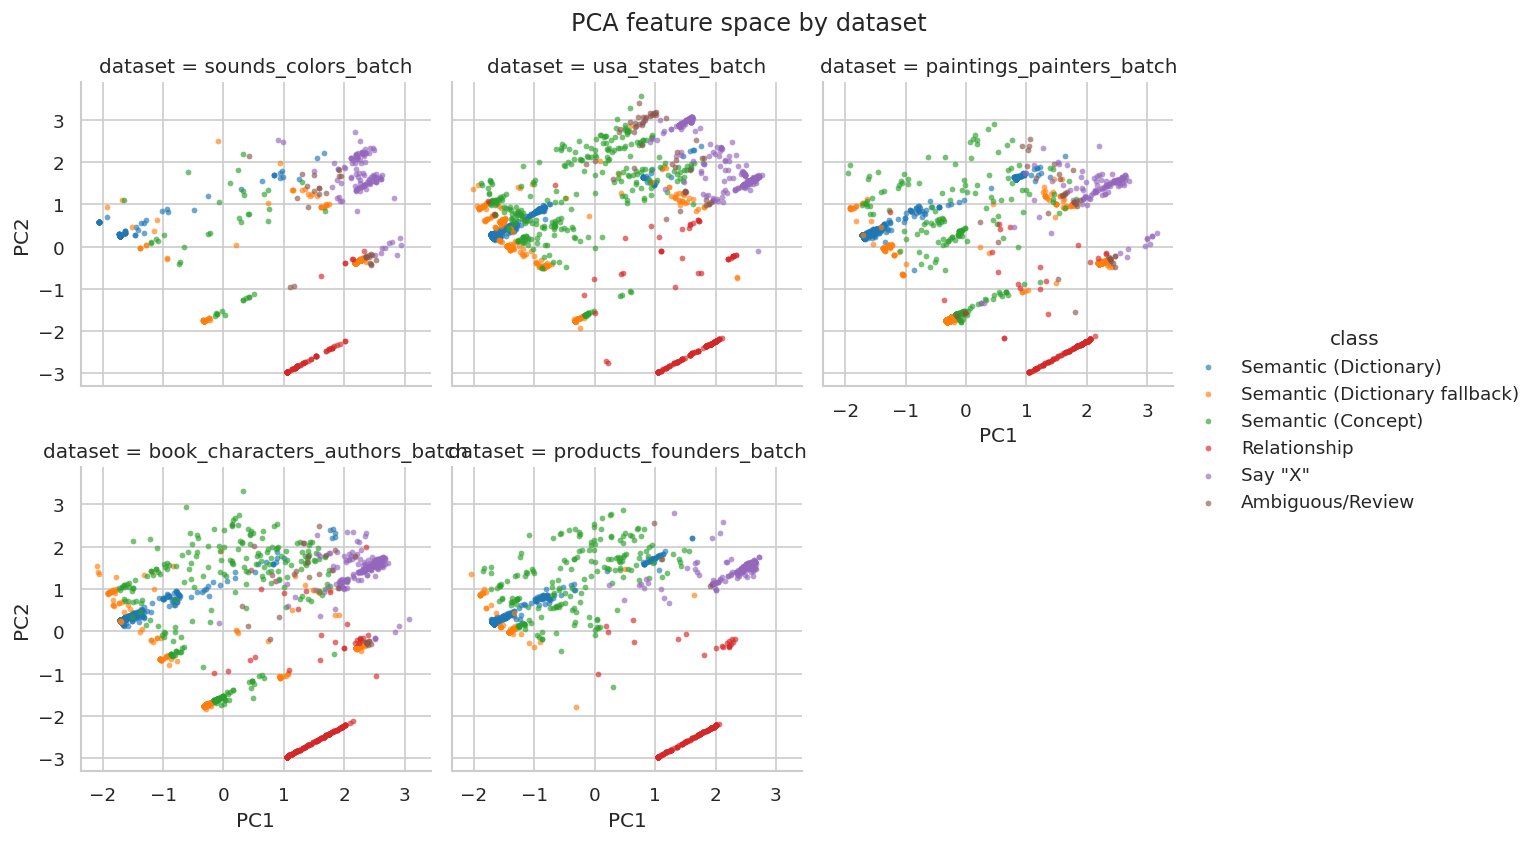

In [24]:
facet = sns.FacetGrid(
    plot_df,
    col="dataset",
    col_wrap=3,
    hue="class",
    hue_order=CLASS_ORDER,
    palette=PALETTE,
    height=3.4,
    sharex=True,
    sharey=True,
)
facet.map_dataframe(sns.scatterplot, x="PC1", y="PC2", s=12, alpha=0.65, linewidth=0)
facet.add_legend(title="class")
facet.fig.suptitle("PCA feature space by dataset", y=1.03)
plt.show()

## Clustering Scores

This is the quantitative check: if unsupervised clusters align with the rule labels, ARI/NMI should be high. The important comparison is `k=4` vs `k=5/6`.

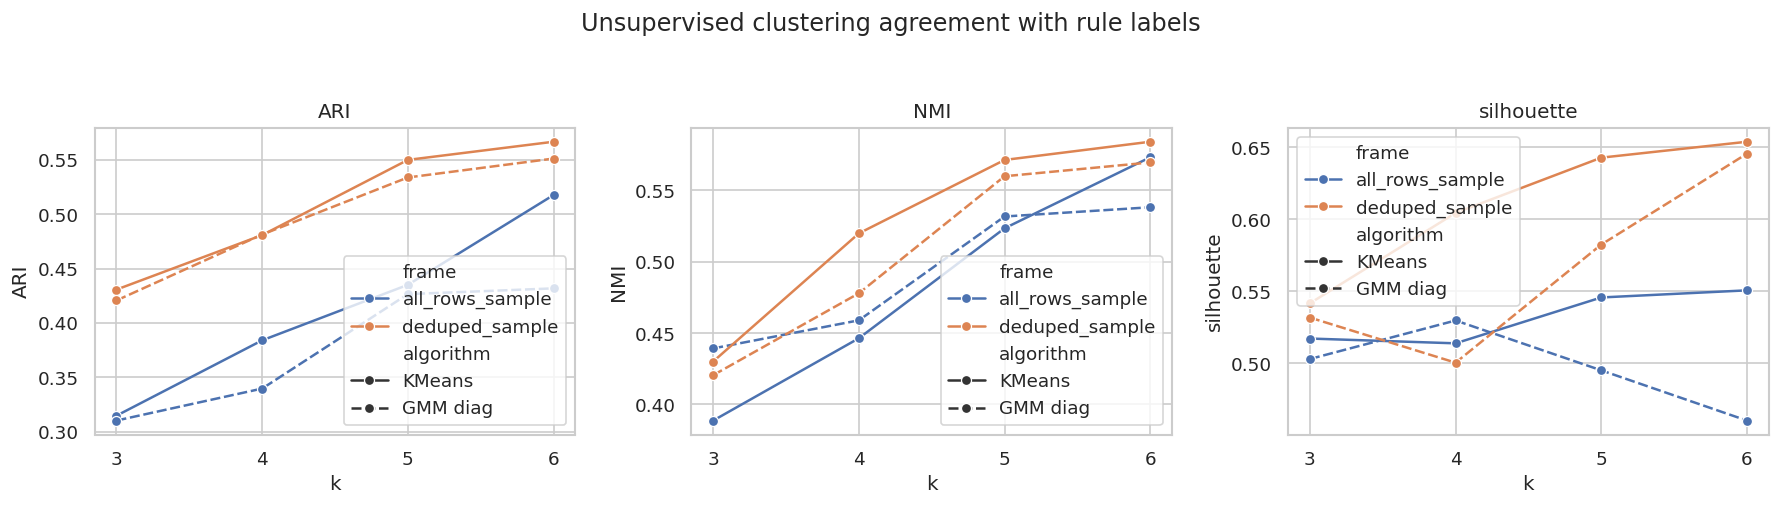

,frame,algorithm,k,ARI,NMI,silhouette
1,all_rows_sample,GMM diag,3,0.310242,0.439297,0.503044
3,all_rows_sample,GMM diag,4,0.339657,0.458963,0.529795
5,all_rows_sample,GMM diag,5,0.426520,0.531698,0.495177
7,all_rows_sample,GMM diag,6,0.431804,0.538165,0.460304
0,all_rows_sample,KMeans,3,0.314715,0.388747,0.517255
2,all_rows_sample,KMeans,4,0.384026,0.446406,0.513933
4,all_rows_sample,KMeans,5,0.435050,0.523430,0.545782
6,all_rows_sample,KMeans,6,0.517642,0.573177,0.550721
9,deduped_sample,GMM diag,3,0.420709,0.420554,0.531806
11,deduped_sample,GMM diag,4,0.481326,0.477916,0.500499


In [25]:
def cluster_scores(frame, frame_name):
    X_frame = StandardScaler().fit_transform(frame[METRIC_COLUMNS])
    y_true = frame["class"].to_numpy()
    rows = []
    for k in [3, 4, 5, 6]:
        km = KMeans(n_clusters=k, n_init=20, random_state=0)
        km_labels = km.fit_predict(X_frame)
        rows.append({
            "frame": frame_name,
            "algorithm": "KMeans",
            "k": k,
            "ARI": adjusted_rand_score(y_true, km_labels),
            "NMI": normalized_mutual_info_score(y_true, km_labels),
            "silhouette": silhouette_score(X_frame, km_labels),
        })

        gmm = GaussianMixture(n_components=k, covariance_type="diag", random_state=0)
        gmm_labels = gmm.fit_predict(X_frame)
        rows.append({
            "frame": frame_name,
            "algorithm": "GMM diag",
            "k": k,
            "ARI": adjusted_rand_score(y_true, gmm_labels),
            "NMI": normalized_mutual_info_score(y_true, gmm_labels),
            "silhouette": silhouette_score(X_frame, gmm_labels),
        })
    return pd.DataFrame(rows)

score_df = pd.concat([
    cluster_scores(manifest.sample(n=min(5000, len(manifest)), random_state=0).copy(), "all_rows_sample"),
    cluster_scores(dedup.sample(n=min(5000, len(dedup)), random_state=0).copy(), "deduped_sample"),
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, metric in zip(axes, ["ARI", "NMI", "silhouette"]):
    sns.lineplot(
        data=score_df,
        x="k",
        y=metric,
        hue="frame",
        style="algorithm",
        marker="o",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xticks([3, 4, 5, 6])
fig.suptitle("Unsupervised clustering agreement with rule labels", y=1.05)
fig.tight_layout()
plt.show()

score_df.sort_values(["frame", "algorithm", "k"])

## KMeans k=4 Confusion Matrix

Rows are unsupervised clusters; columns are rule labels. Row-normalization shows what each discovered cluster mostly contains.

/tmp/ipykernel_43622/935301047.py:8: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm / cm.sum(axis=1, keepdims=True)
<repo>/.venv/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
<repo>/.venv/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


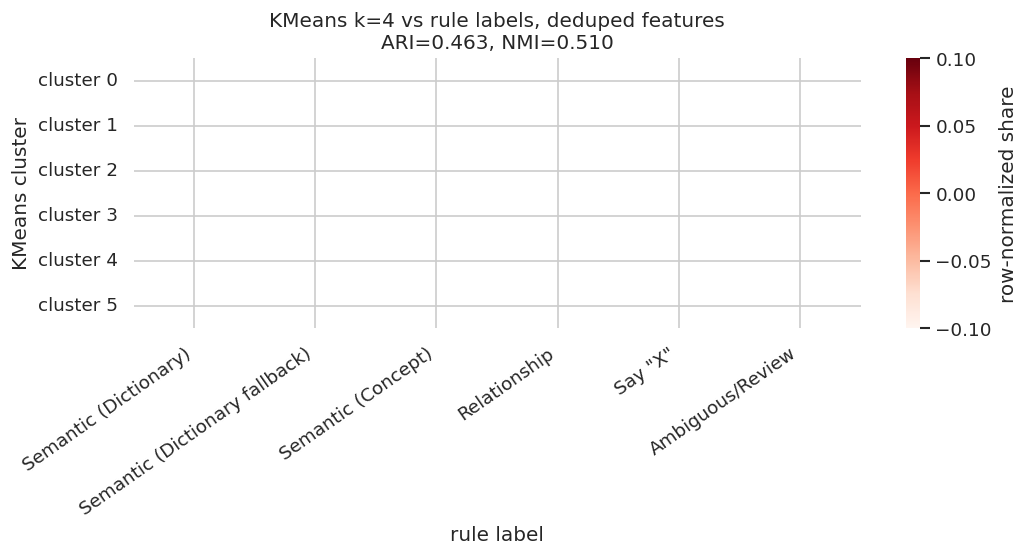

In [26]:
X_dedup = StandardScaler().fit_transform(dedup[METRIC_COLUMNS])
y_dedup = dedup["class"].to_numpy()
km4 = KMeans(n_clusters=4, n_init=20, random_state=0)
cluster_labels = km4.fit_predict(X_dedup)

observed_classes = [label for label in CLASS_ORDER if label in set(y_dedup)]
cm = confusion_matrix(y_dedup, cluster_labels, labels=observed_classes).T
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(
    cm_norm,
    annot=cm,
    fmt="d",
    cmap="Reds",
    xticklabels=observed_classes,
    yticklabels=[f"cluster {i}" for i in range(cm.shape[0])],
    cbar_kws={"label": "row-normalized share"},
    ax=ax,
)
ax.set_xlabel("rule label")
ax.set_ylabel("KMeans cluster")
ax.set_title(
    "KMeans k=4 vs rule labels, deduped features\n"
    f"ARI={adjusted_rand_score(y_dedup, cluster_labels):.3f}, "
    f"NMI={normalized_mutual_info_score(y_dedup, cluster_labels):.3f}"
)
plt.xticks(rotation=35, ha="right")
fig.tight_layout()
plt.show()

## Threshold Sensitivity

Low flip rates mean the tree is not relying on many points sitting exactly at the decision boundaries. This does not prove the labels are mechanistic; it only weakens the arbitrary-threshold explanation.

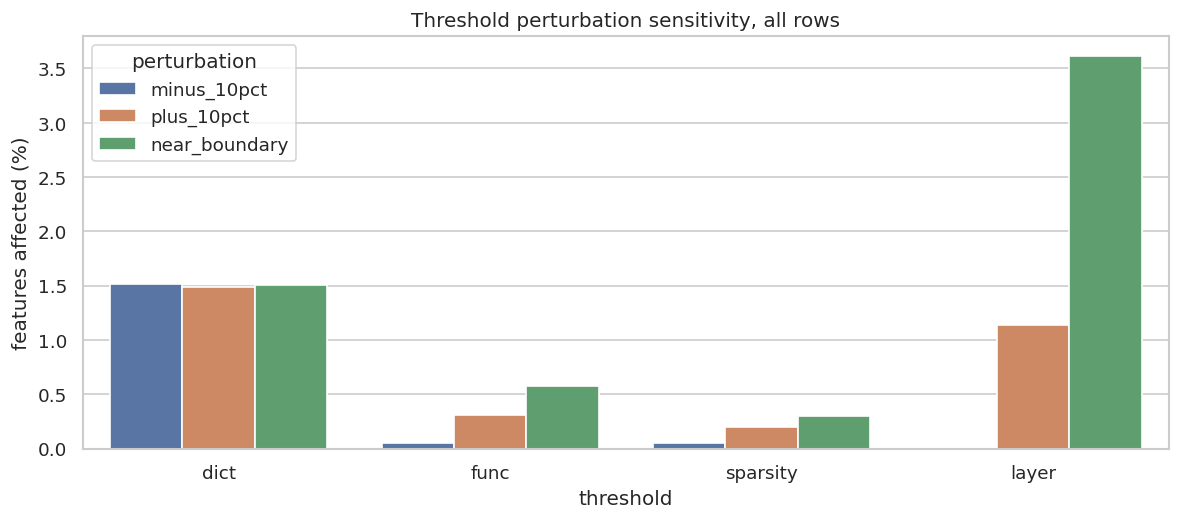

,threshold,perturbation,flip_rate,flip_pct
0,dict,minus_10pct,0.015171,1.517058
1,dict,plus_10pct,0.014919,1.491893
2,dict,near_boundary,0.015099,1.509868
3,func,minus_10pct,0.000539,0.053924
4,func,plus_10pct,0.003092,0.309163
5,func,near_boundary,0.005752,0.575188
6,sparsity,minus_10pct,0.000539,0.053924
7,sparsity,plus_10pct,0.001941,0.194126
8,sparsity,near_boundary,0.002948,0.294784
9,layer,minus_10pct,0.000000,0.000000


In [27]:
sensitivity_df = pd.DataFrame(results["sensitivity"])
sensitivity_df["flip_pct"] = 100 * sensitivity_df["flip_rate"]

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(
    data=sensitivity_df,
    x="threshold",
    y="flip_pct",
    hue="perturbation",
    ax=ax,
)
ax.set_ylabel("features affected (%)")
ax.set_xlabel("threshold")
ax.set_title("Threshold perturbation sensitivity, all rows")
ax.legend(title="perturbation")
fig.tight_layout()
plt.show()

sensitivity_df

## Pairwise Scatter Across All 6 Metric Axes

PCA and t-SNE compress the 6-D space into 2 dimensions and can hide structure. The pairplot below shows every 2-D slice (15 unique pairs) plus the marginals on the diagonal, coloured by the rule label. Threshold lines from the decision tree are drawn on the relevant marginals.

The first figure uses the deduped frame (one row per global `(layer, feature)`); the next section repeats the same plot inside each dataset to test cross-domain consistency.

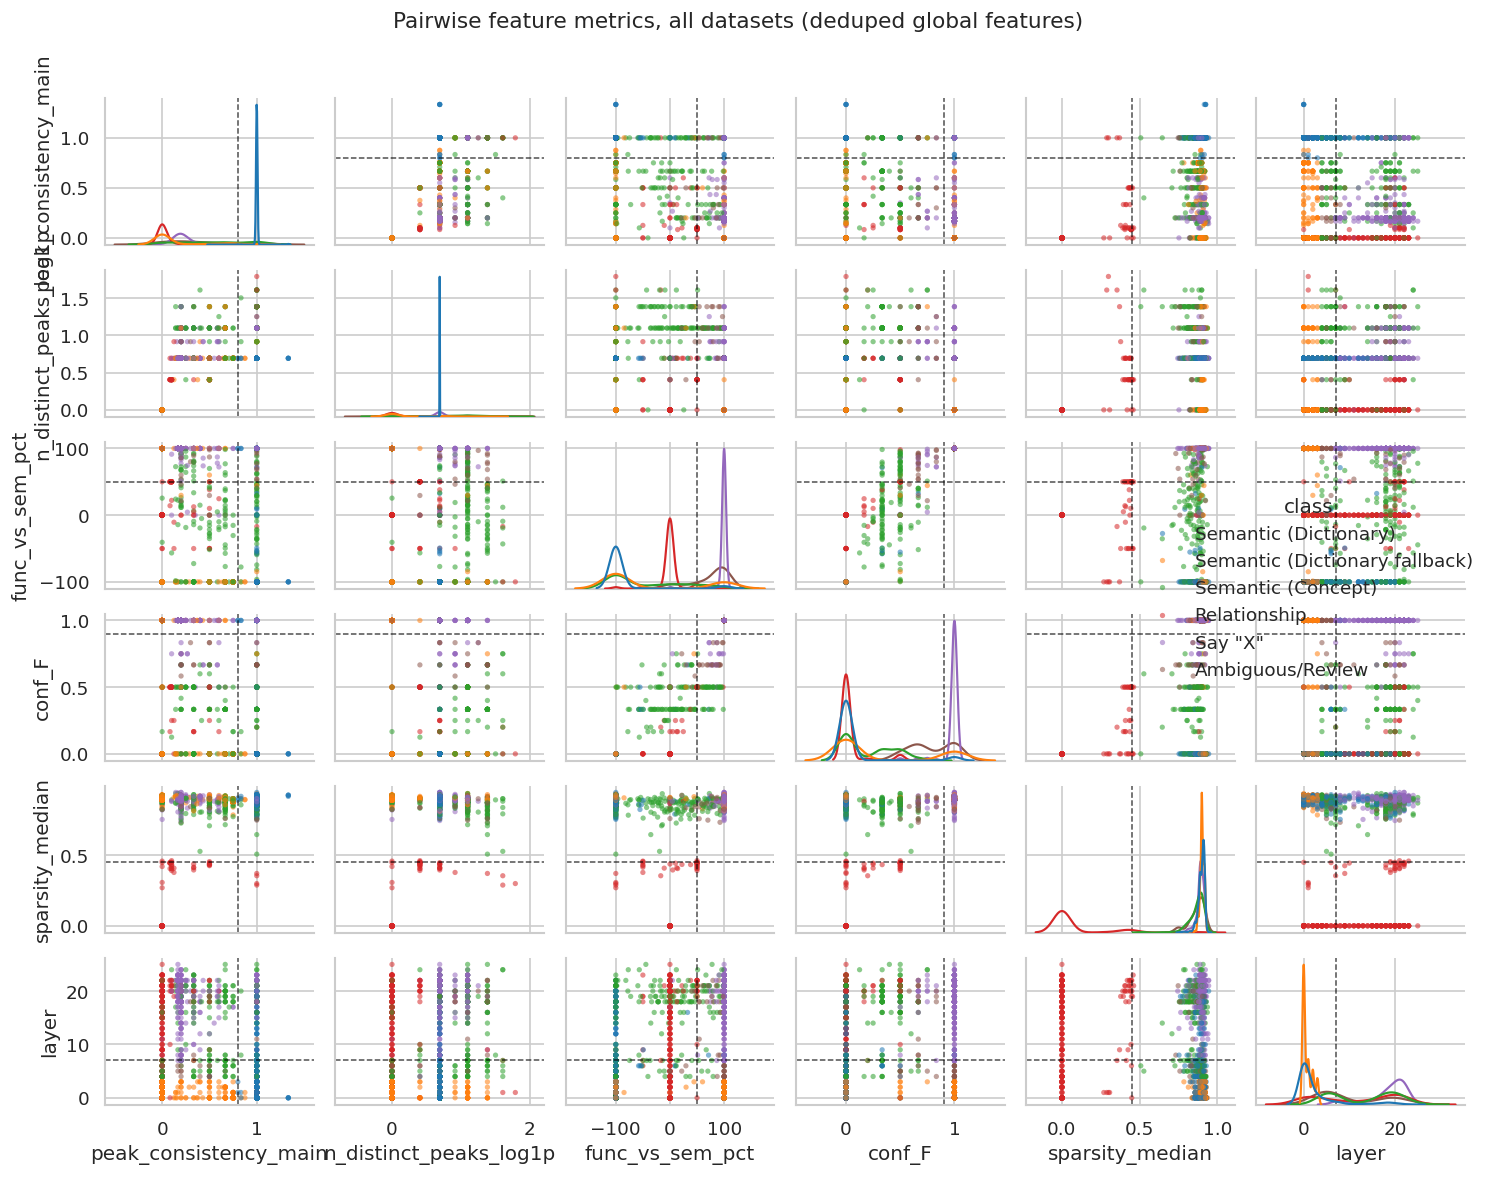

In [28]:
PAIRPLOT_AXES = [
    "peak_consistency_main",
    "n_distinct_peaks_log1p",
    "func_vs_sem_pct",
    "conf_F",
    "sparsity_median",
    "layer",
]
THRESHOLD_LINES = {
    "peak_consistency_main": 0.80,
    "func_vs_sem_pct": 50.0,
    "sparsity_median": 0.45,
    "layer": 7.0,
    "conf_F": 0.90,
}

def annotate_thresholds(grid):
    n = len(grid.axes)
    for i, axis in enumerate(PAIRPLOT_AXES):
        if axis not in THRESHOLD_LINES:
            continue
        threshold = THRESHOLD_LINES[axis]
        for j in range(n):
            ax = grid.axes[j, i]
            if ax is None:
                continue
            ax.axvline(threshold, color="black", linestyle="--", linewidth=0.9, alpha=0.7)
        for k in range(n):
            ax = grid.axes[i, k]
            if ax is None or k == i:
                continue
            ax.axhline(threshold, color="black", linestyle="--", linewidth=0.9, alpha=0.7)

def make_pairplot(frame, title, sample_n=2500):
    if len(frame) > sample_n:
        frame = frame.sample(n=sample_n, random_state=0)
    grid = sns.pairplot(
        frame,
        vars=PAIRPLOT_AXES,
        hue="class",
        hue_order=[c for c in CLASS_ORDER if c in frame["class"].unique()],
        palette=PALETTE,
        diag_kind="kde",
        plot_kws={"s": 10, "alpha": 0.55, "linewidth": 0},
        diag_kws={"common_norm": False, "fill": False, "linewidth": 1.3},
        height=1.6,
        corner=False,
    )
    annotate_thresholds(grid)
    grid.fig.suptitle(title, y=1.02, fontsize=13)
    grid.fig.tight_layout()
    return grid

make_pairplot(dedup, "Pairwise feature metrics, all datasets (deduped global features)")
plt.show()

## Pairwise Scatter Per Dataset

One pairplot per dataset, computed from the all-rows manifest filtered to that dataset. If the rule classes occupy different regions across domains, the colour structure across the 5 figures will look qualitatively different. If the partition transfers, the colour layout should be consistent.

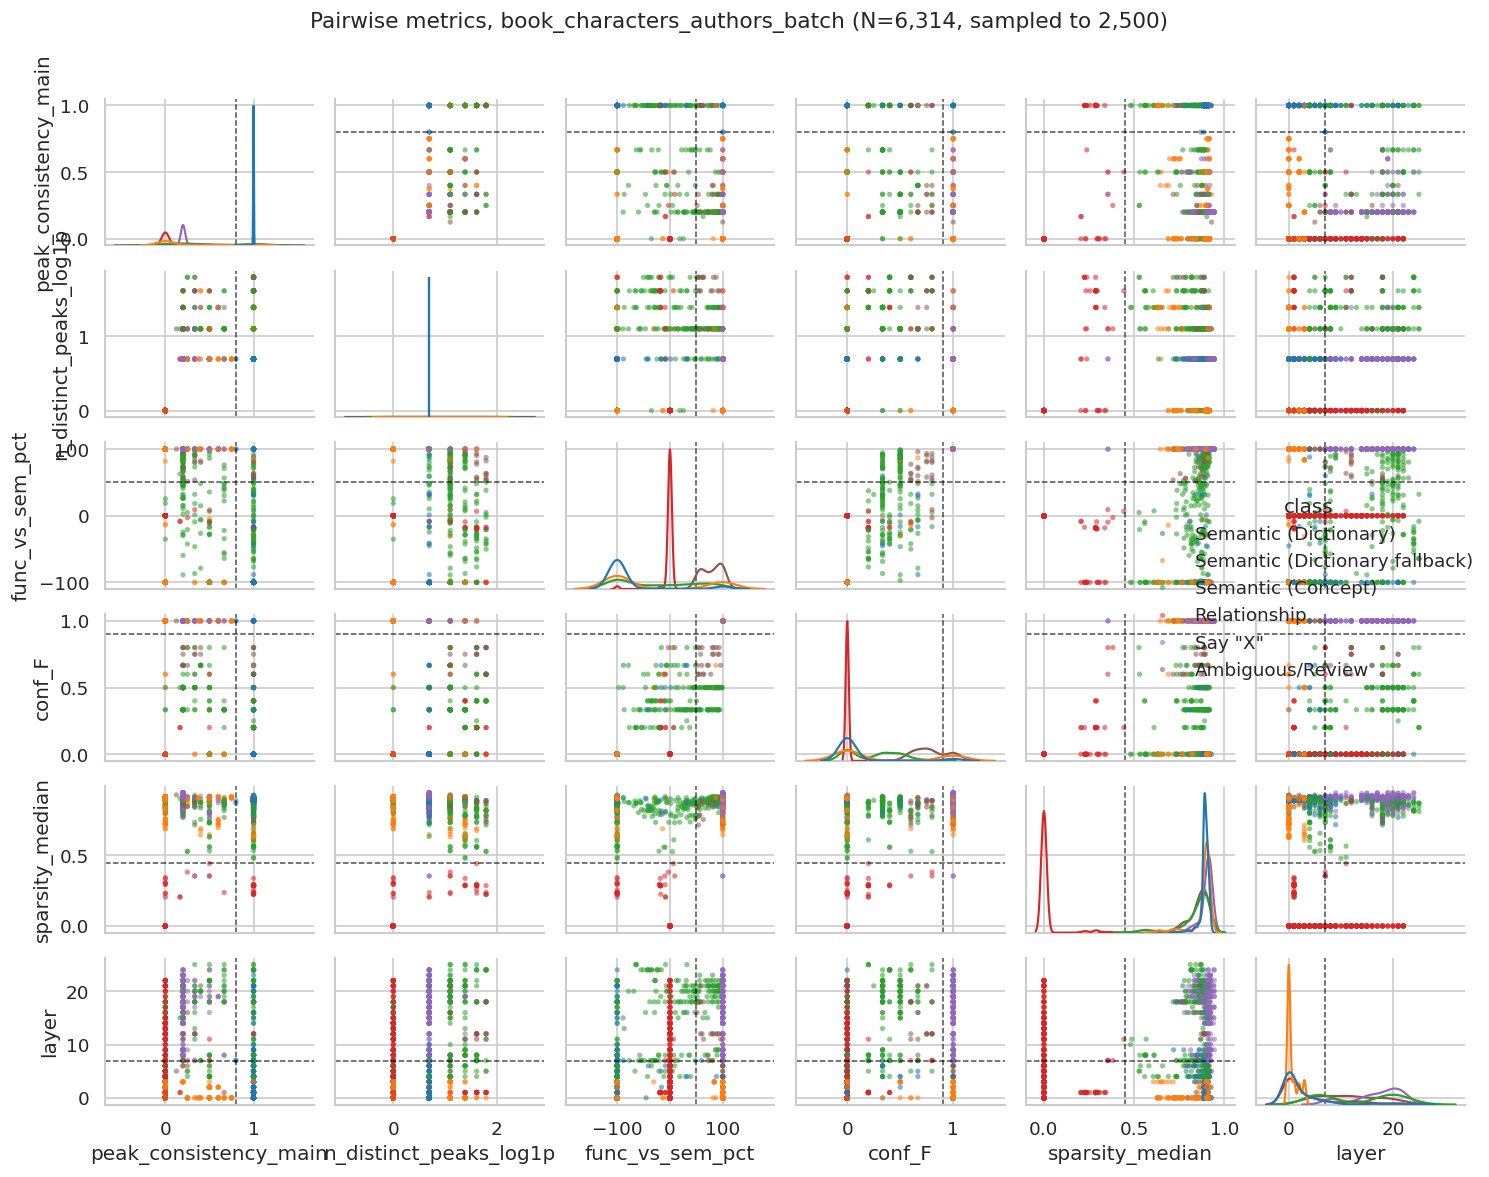

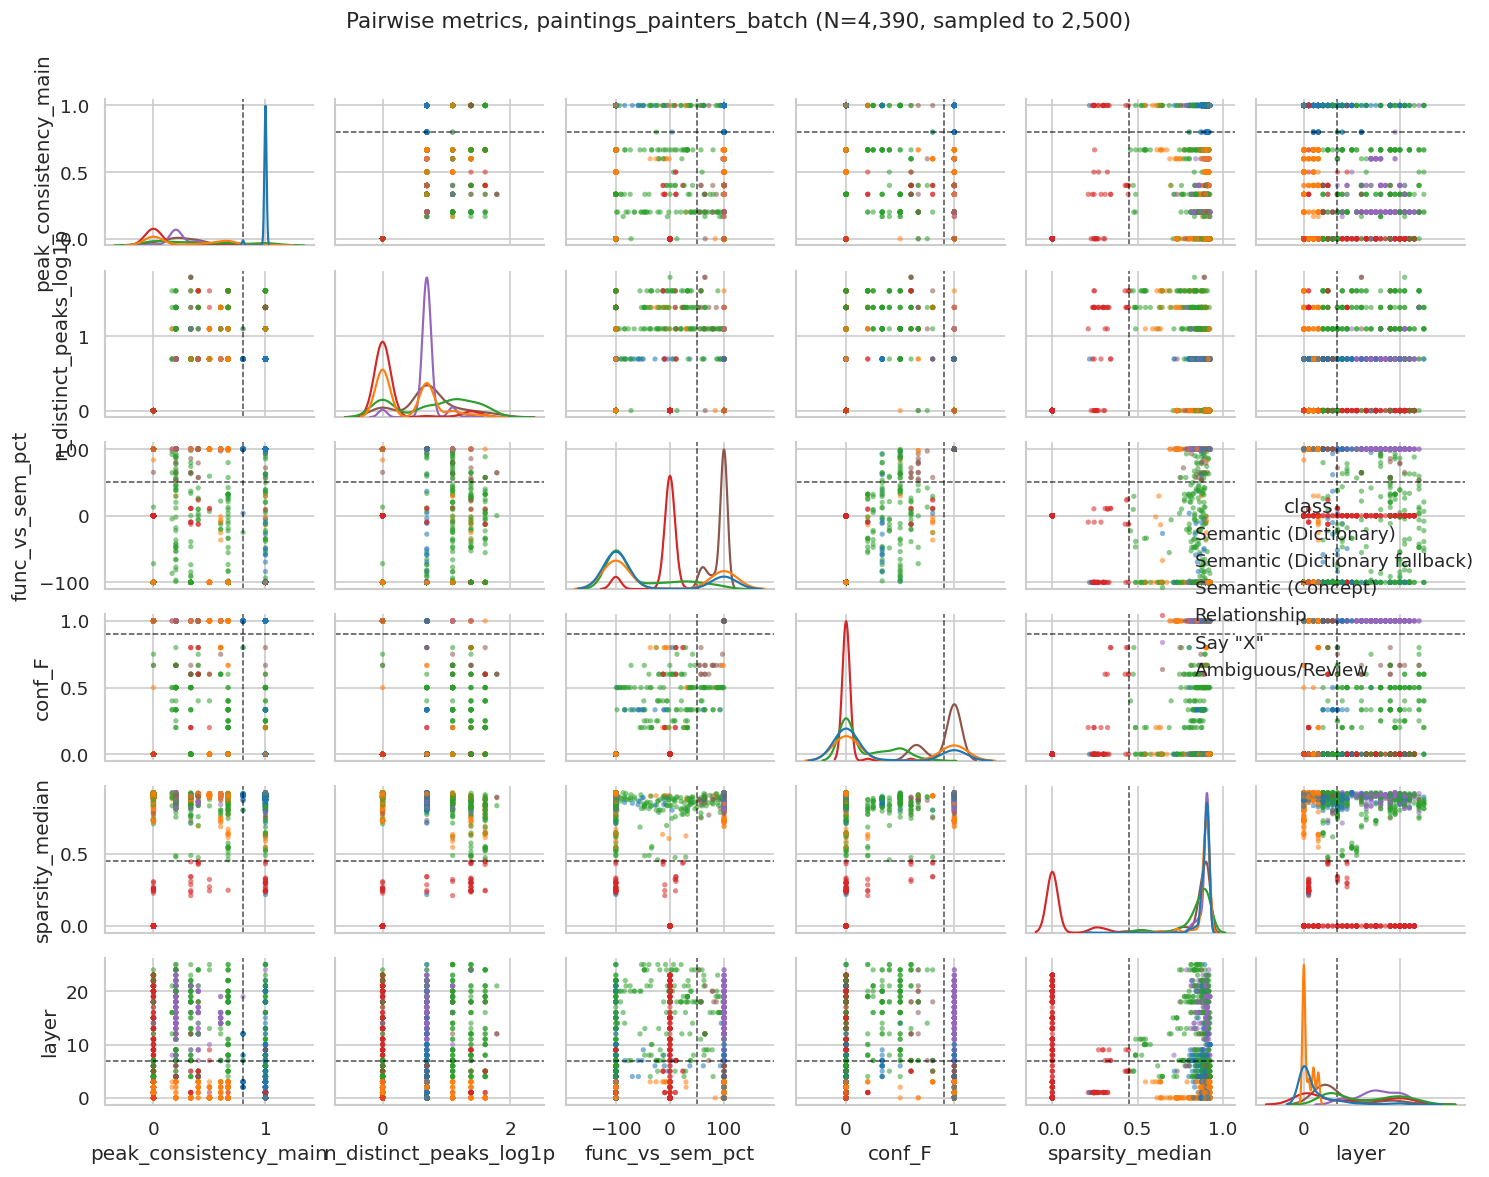

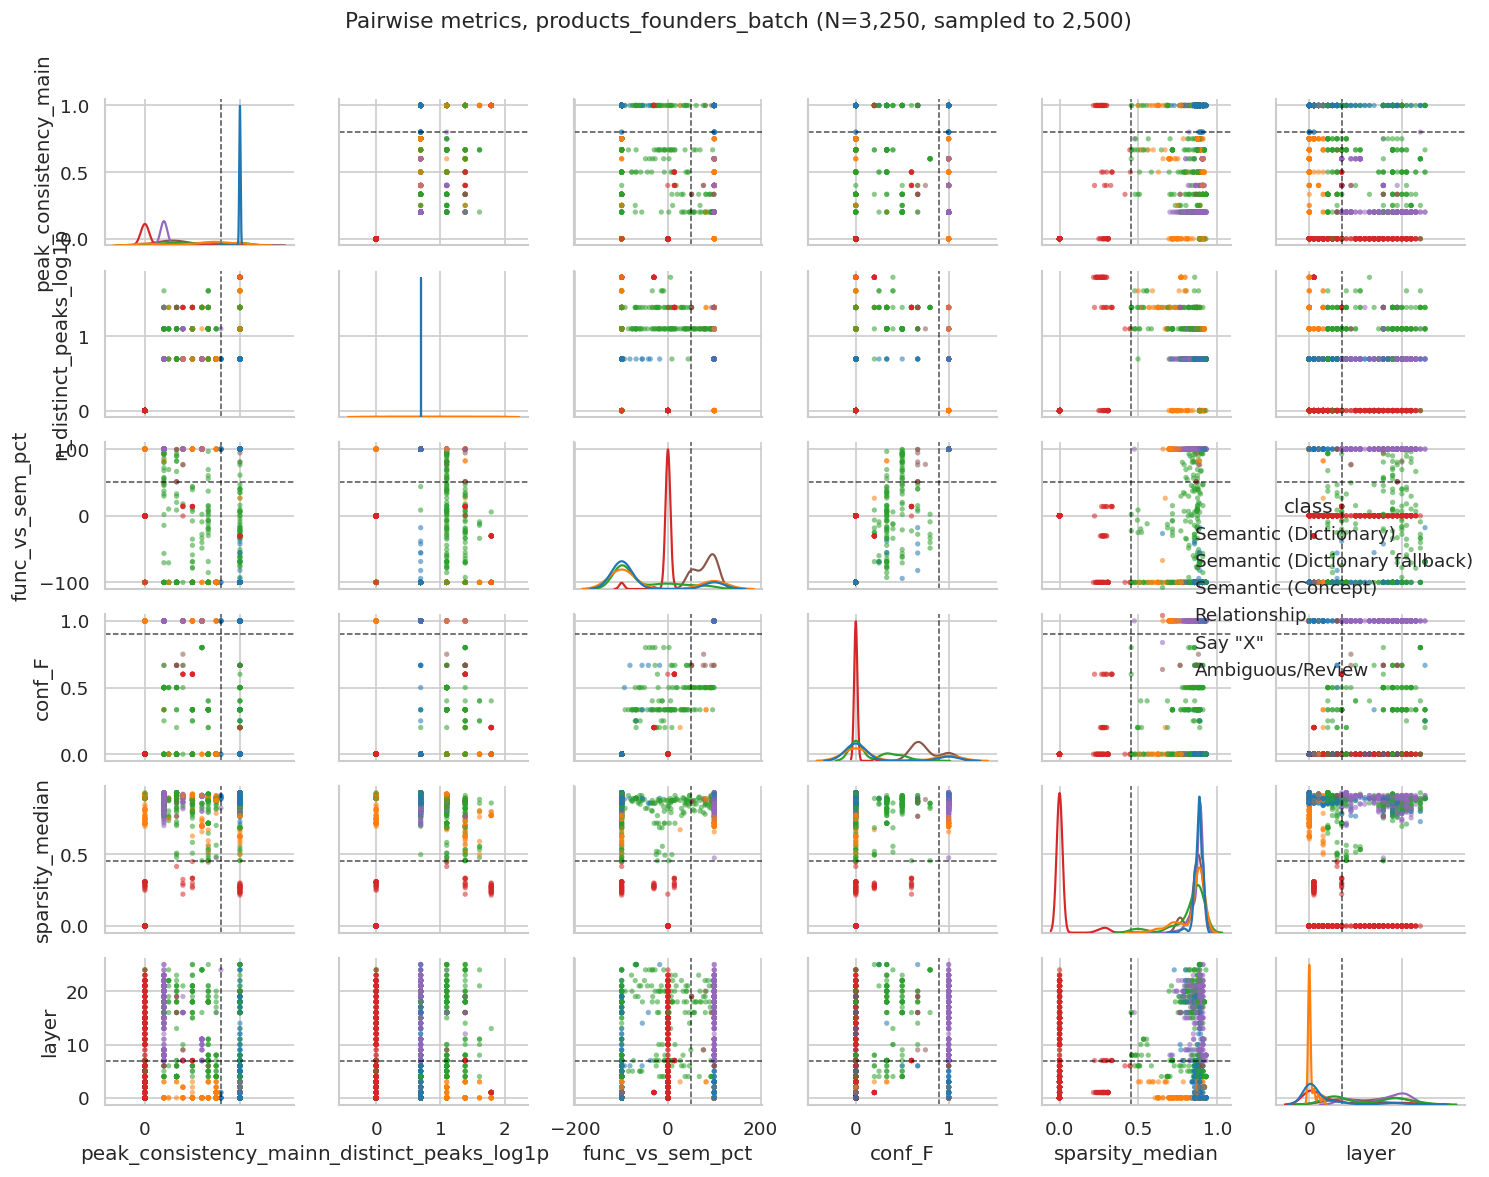

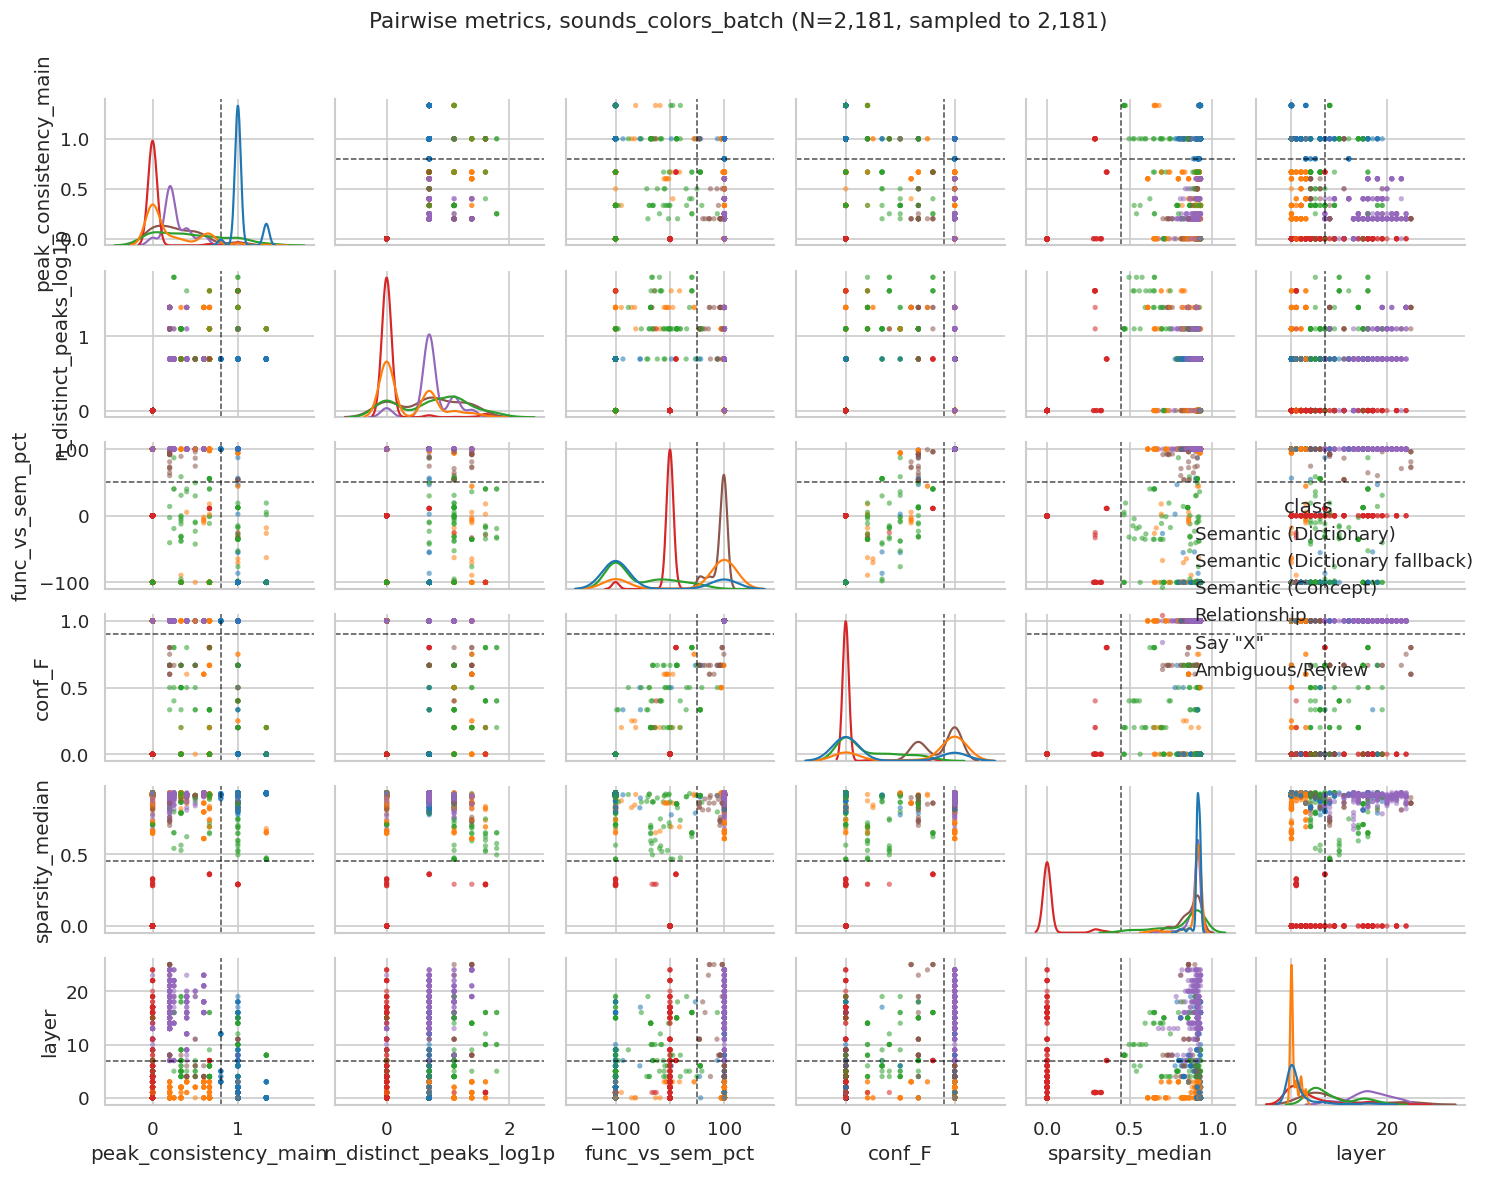

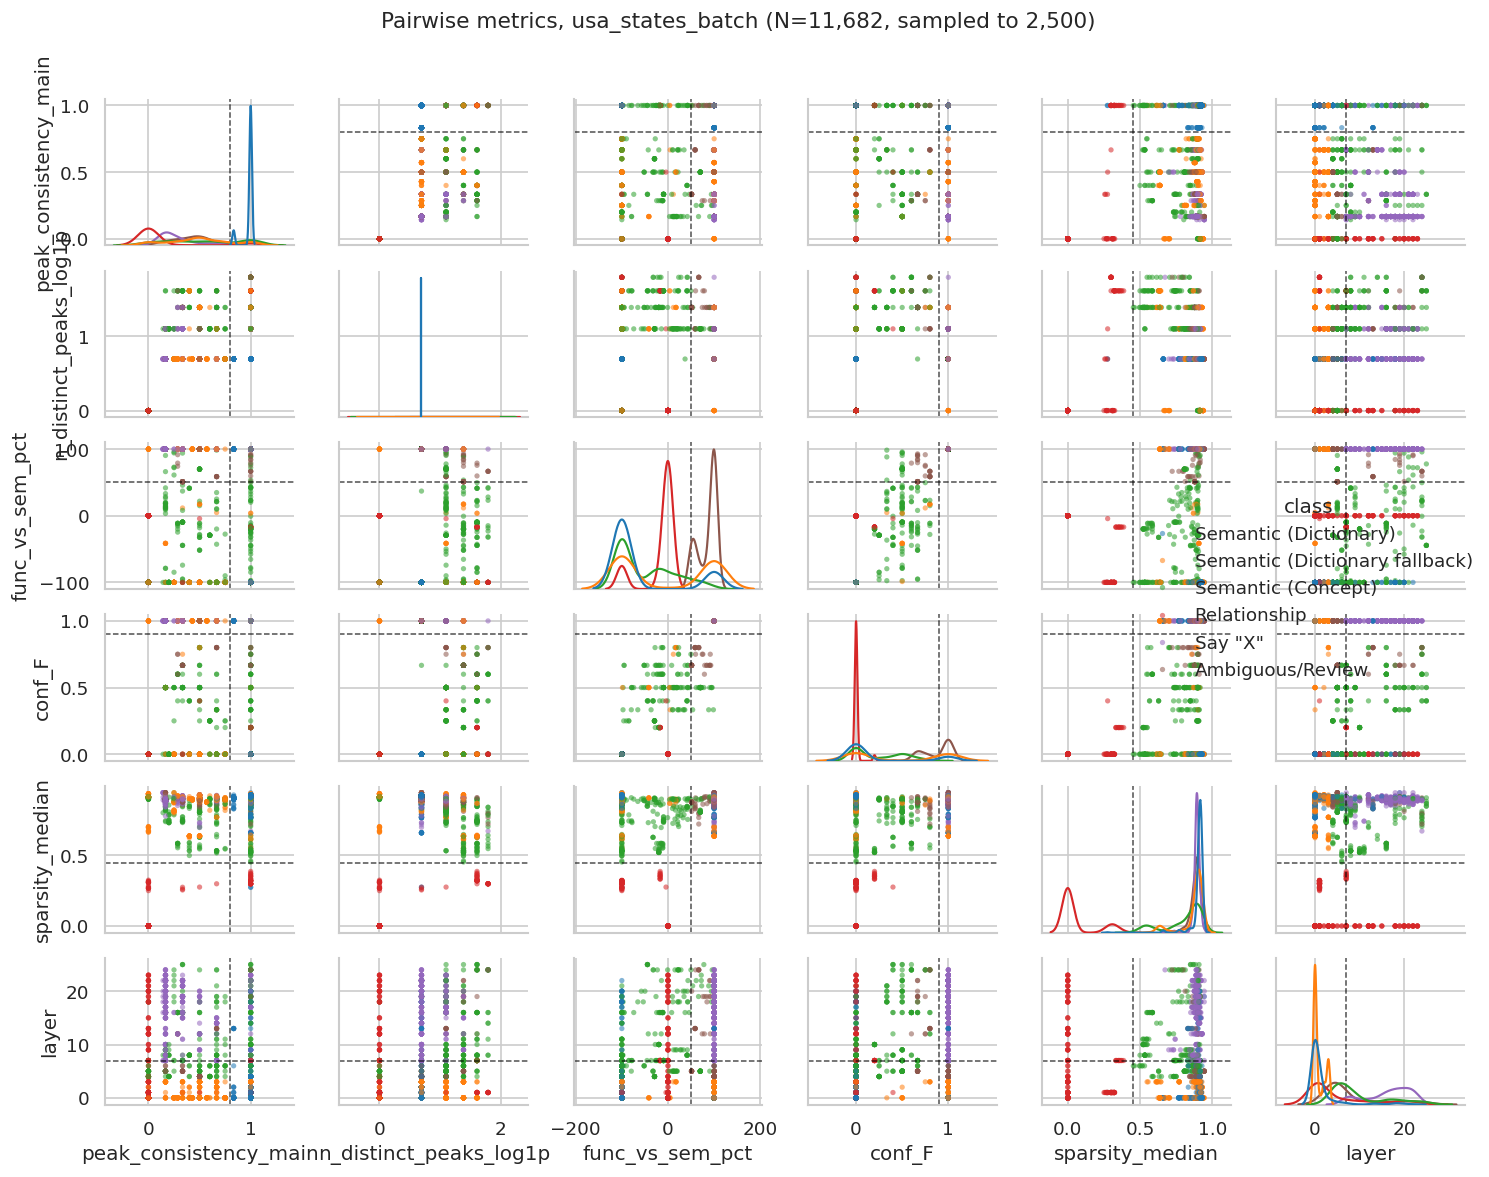

In [29]:
for dataset_name in sorted(manifest["dataset"].unique()):
    subset = manifest[manifest["dataset"] == dataset_name]
    n = len(subset)
    make_pairplot(
        subset,
        f"Pairwise metrics, {dataset_name} (N={n:,}, sampled to {min(n, 2500):,})",
    )
    plt.show()

## Per-Dataset t-SNE

Same projection technique as the combined t-SNE, but computed inside each dataset. If the rule classes occupy the same regions of the manifold across domains, each panel should look qualitatively like the others. If the natural geometry is domain-specific, the panels will diverge.

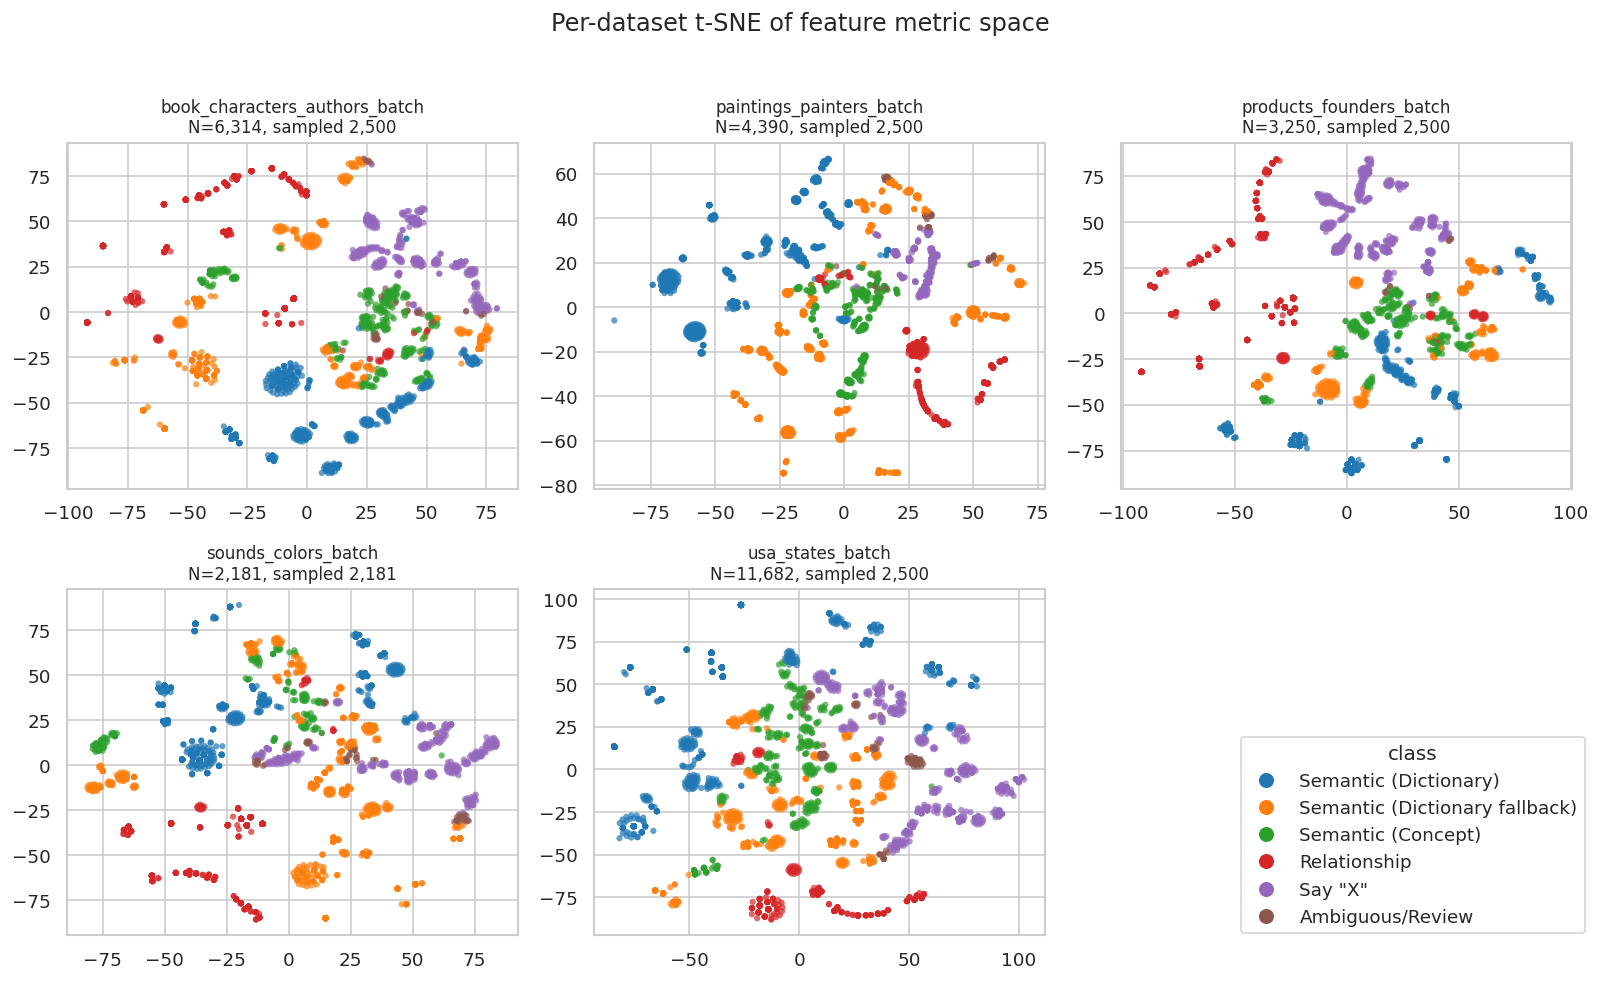

In [30]:
def per_dataset_tsne(frame, sample_n=2500, perplexity=30):
    panels = []
    for dataset_name in sorted(frame["dataset"].unique()):
        subset = frame[frame["dataset"] == dataset_name]
        sample_size = min(len(subset), sample_n)
        sub = subset.sample(n=sample_size, random_state=0).copy()
        Xd = StandardScaler().fit_transform(sub[METRIC_COLUMNS])
        coords = TSNE(
            n_components=2,
            init="pca",
            learning_rate="auto",
            perplexity=min(perplexity, max(5, sample_size // 5)),
            random_state=0,
        ).fit_transform(Xd)
        sub["TSNE1"] = coords[:, 0]
        sub["TSNE2"] = coords[:, 1]
        panels.append((dataset_name, sub, len(subset), sample_size))
    return panels

panels = per_dataset_tsne(manifest)

n_cols = 3
n_rows = (len(panels) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.0), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)
for ax, (dataset_name, sub, total_n, sample_size) in zip(axes.flat, panels):
    ax.set_visible(True)
    sns.scatterplot(
        data=sub,
        x="TSNE1",
        y="TSNE2",
        hue="class",
        hue_order=[c for c in CLASS_ORDER if c in sub["class"].unique()],
        palette=PALETTE,
        s=14,
        alpha=0.7,
        linewidth=0,
        ax=ax,
        legend=False,
    )
    ax.set_title(f"{dataset_name}\nN={total_n:,}, sampled {sample_size:,}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

handles, labels = [], []
for cls in CLASS_ORDER:
    if cls in manifest["class"].unique():
        handles.append(plt.Line2D([0], [0], marker="o", linestyle="", color=PALETTE[cls], markersize=8))
        labels.append(cls)
fig.legend(handles, labels, title="class", loc="lower right", bbox_to_anchor=(0.99, 0.05))
fig.suptitle("Per-dataset t-SNE of feature metric space", y=1.02)
fig.tight_layout()
plt.show()

## UMAP

UMAP preserves more of the global geometry than t-SNE: distances between clusters are more interpretable, and connected manifolds tend to stay connected. It is also faster than t-SNE on this dataset size.

The combined view is followed by a per-dataset facet for direct comparison with the per-dataset t-SNE above.

<repo>/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
<repo>/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


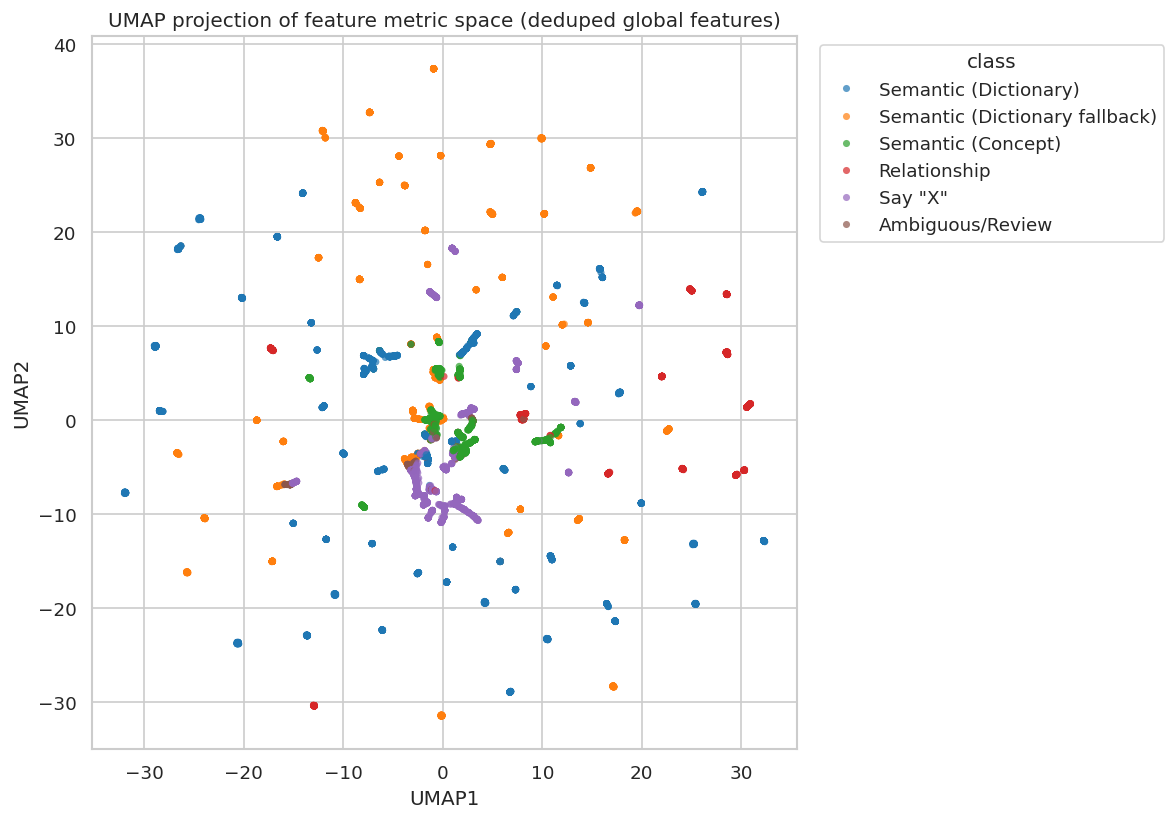

In [31]:
import umap

X_dedup_std = StandardScaler().fit_transform(dedup[METRIC_COLUMNS])
umap_xy = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
).fit_transform(X_dedup_std)

umap_df = dedup.copy()
umap_df["UMAP1"] = umap_xy[:, 0]
umap_df["UMAP2"] = umap_xy[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="class",
    hue_order=[c for c in CLASS_ORDER if c in umap_df["class"].unique()],
    palette=PALETTE,
    s=18,
    alpha=0.7,
    linewidth=0,
    ax=ax,
)
ax.set_title("UMAP projection of feature metric space (deduped global features)")
ax.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

<repo>/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<repo>/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<repo>/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<repo>/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<repo>/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<repo>/.venv/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due t

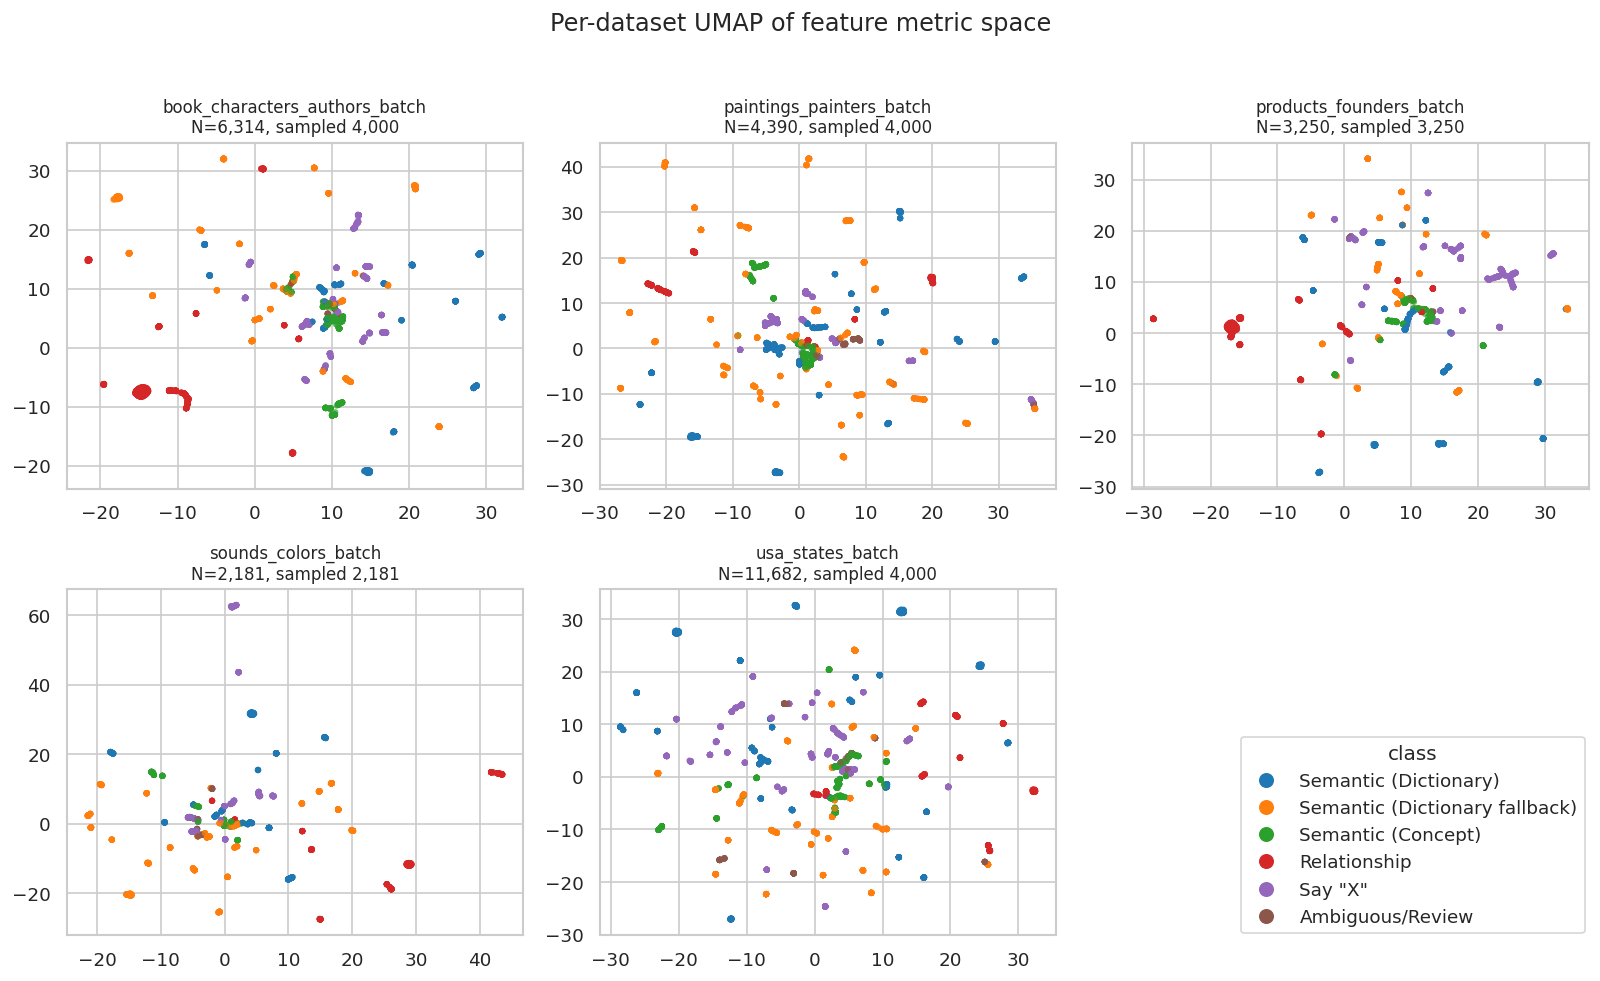

In [32]:
def per_dataset_umap(frame, sample_n=4000):
    panels = []
    for dataset_name in sorted(frame["dataset"].unique()):
        subset = frame[frame["dataset"] == dataset_name]
        sample_size = min(len(subset), sample_n)
        sub = subset.sample(n=sample_size, random_state=0).copy()
        Xd = StandardScaler().fit_transform(sub[METRIC_COLUMNS])
        coords = umap.UMAP(
            n_components=2,
            n_neighbors=min(30, max(5, sample_size // 50)),
            min_dist=0.1,
            metric="euclidean",
            random_state=0,
        ).fit_transform(Xd)
        sub["UMAP1"] = coords[:, 0]
        sub["UMAP2"] = coords[:, 1]
        panels.append((dataset_name, sub, len(subset), sample_size))
    return panels

umap_panels = per_dataset_umap(manifest)

n_cols = 3
n_rows = (len(umap_panels) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.0), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)
for ax, (dataset_name, sub, total_n, sample_size) in zip(axes.flat, umap_panels):
    ax.set_visible(True)
    sns.scatterplot(
        data=sub,
        x="UMAP1",
        y="UMAP2",
        hue="class",
        hue_order=[c for c in CLASS_ORDER if c in sub["class"].unique()],
        palette=PALETTE,
        s=14,
        alpha=0.7,
        linewidth=0,
        ax=ax,
        legend=False,
    )
    ax.set_title(f"{dataset_name}\nN={total_n:,}, sampled {sample_size:,}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

handles, labels = [], []
for cls in CLASS_ORDER:
    if cls in manifest["class"].unique():
        handles.append(plt.Line2D([0], [0], marker="o", linestyle="", color=PALETTE[cls], markersize=8))
        labels.append(cls)
fig.legend(handles, labels, title="class", loc="lower right", bbox_to_anchor=(0.99, 0.05))
fig.suptitle("Per-dataset UMAP of feature metric space", y=1.02)
fig.tight_layout()
plt.show()

## HDBSCAN - Density-Based Clustering

KMeans and GMM force the data into a fixed number of clusters. HDBSCAN does not: it discovers clusters from the local density structure, returns "noise" for points it cannot assign, and yields a number of natural clusters as part of its output. This is the cleanest way to ask "how many natural feature classes are actually there?"

The reported ARI/NMI compare the discovered clusters to the rule labels, ignoring noise points. The number of discovered clusters is the headline number.

In [33]:
from sklearn.cluster import HDBSCAN

def run_hdbscan(frame, label, min_cluster_sizes=(40, 80, 150)):
    Xs = StandardScaler().fit_transform(frame[METRIC_COLUMNS])
    y_true = frame["class"].to_numpy()
    rows = []
    for mcs in min_cluster_sizes:
        labels = HDBSCAN(
            min_cluster_size=mcs,
            min_samples=None,
            cluster_selection_method="eom",
        ).fit_predict(Xs)
        n_clusters = labels.max() + 1
        n_noise = int((labels == -1).sum())
        mask = labels != -1
        if mask.sum() > 1 and len(set(labels[mask])) > 1:
            ari_val = adjusted_rand_score(y_true[mask], labels[mask])
            nmi_val = normalized_mutual_info_score(y_true[mask], labels[mask])
            sil_val = silhouette_score(Xs[mask], labels[mask])
        else:
            ari_val = nmi_val = sil_val = float("nan")
        rows.append({
            "frame": label,
            "min_cluster_size": mcs,
            "n_clusters": int(n_clusters),
            "n_noise": n_noise,
            "noise_pct": 100 * n_noise / len(labels),
            "ARI_excl_noise": ari_val,
            "NMI_excl_noise": nmi_val,
            "silhouette_excl_noise": sil_val,
        })
    return pd.DataFrame(rows)

hdb_df = pd.concat([
    run_hdbscan(dedup, "deduped"),
    run_hdbscan(manifest.sample(n=min(8000, len(manifest)), random_state=0).copy(), "all_rows_sample"),
], ignore_index=True)

hdb_df

,frame,min_cluster_size,n_clusters,n_noise,noise_pct,ARI_excl_noise,NMI_excl_noise,silhouette_excl_noise
0,deduped,40,54,2376,28.578302,0.107409,0.500063,0.556742
1,deduped,80,26,2770,33.317296,0.220564,0.564970,0.556913
2,deduped,150,13,2765,33.257157,0.318756,0.605053,0.741415
3,all_rows_sample,40,58,2253,28.162500,0.180491,0.535457,0.610039
4,all_rows_sample,80,25,2952,36.900000,0.320471,0.614621,0.642524
5,all_rows_sample,150,11,3730,46.625000,0.457532,0.668722,0.798408


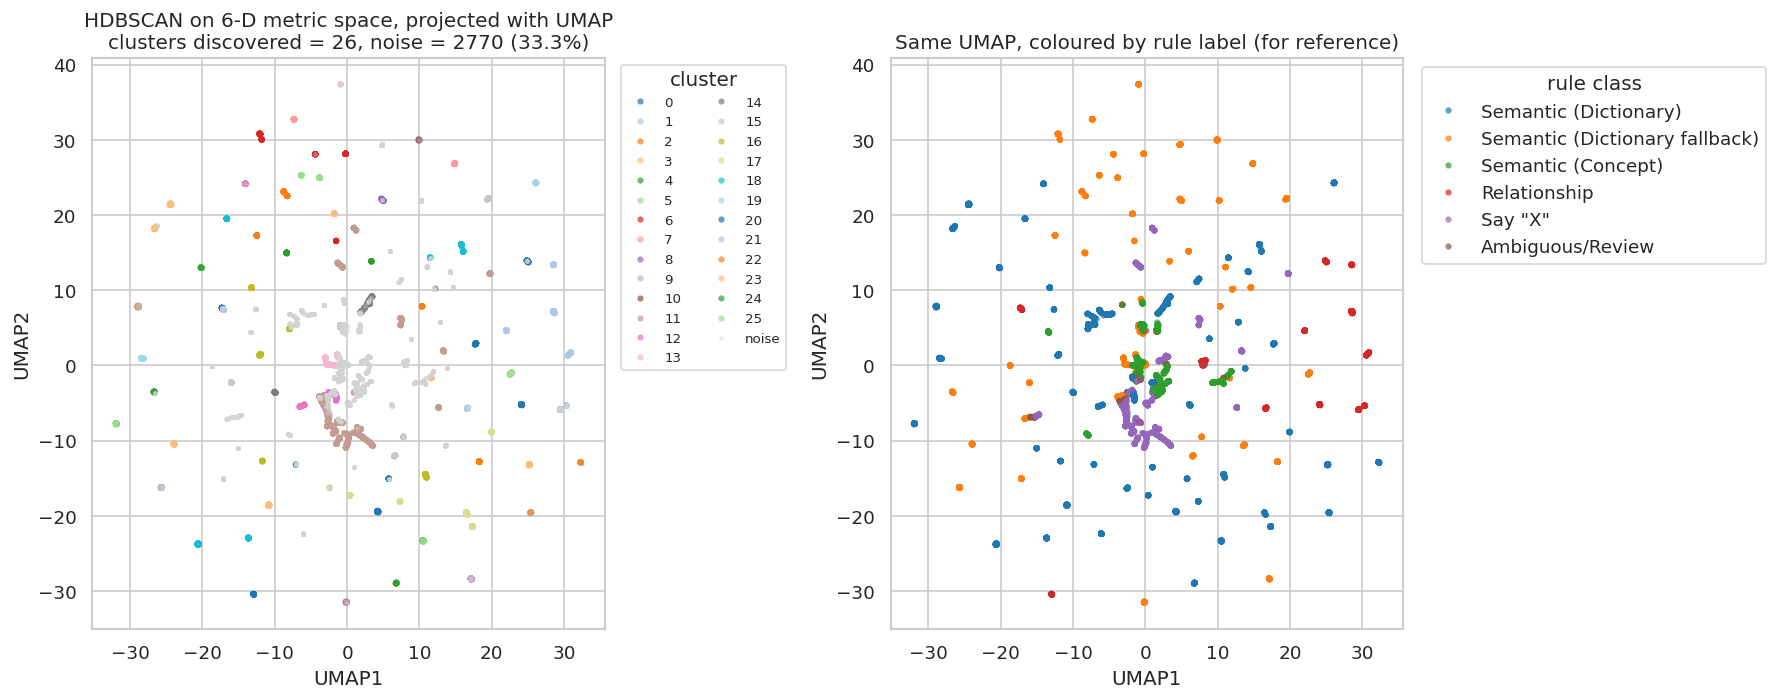

In [34]:
X_dedup_std = StandardScaler().fit_transform(dedup[METRIC_COLUMNS])
hdb = HDBSCAN(min_cluster_size=80, cluster_selection_method="eom").fit(X_dedup_std)
hdb_labels = hdb.labels_

dedup_view = dedup.copy()
dedup_view["hdbscan"] = hdb_labels
dedup_view["UMAP1"] = umap_xy[:, 0]
dedup_view["UMAP2"] = umap_xy[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette_clusters = sns.color_palette("tab20", n_colors=max(hdb_labels) + 2)
sns.scatterplot(
    data=dedup_view[dedup_view["hdbscan"] != -1],
    x="UMAP1", y="UMAP2",
    hue="hdbscan",
    palette=[palette_clusters[i] for i in sorted(set(hdb_labels) - {-1})],
    s=14, alpha=0.7, linewidth=0,
    ax=axes[0],
)
sns.scatterplot(
    data=dedup_view[dedup_view["hdbscan"] == -1],
    x="UMAP1", y="UMAP2",
    color="lightgray", s=8, alpha=0.4, linewidth=0,
    ax=axes[0],
    label="noise",
)
axes[0].set_title(
    f"HDBSCAN on 6-D metric space, projected with UMAP\n"
    f"clusters discovered = {hdb_labels.max() + 1}, noise = {(hdb_labels == -1).sum()} ({100 * (hdb_labels == -1).mean():.1f}%)"
)
axes[0].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2, fontsize=8)

sns.scatterplot(
    data=dedup_view,
    x="UMAP1", y="UMAP2",
    hue="class",
    hue_order=[c for c in CLASS_ORDER if c in dedup_view["class"].unique()],
    palette=PALETTE,
    s=14, alpha=0.7, linewidth=0,
    ax=axes[1],
)
axes[1].set_title("Same UMAP, coloured by rule label (for reference)")
axes[1].legend(title="rule class", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

## Hierarchical Clustering With Dendrogram

Agglomerative (bottom-up) clustering builds a full hierarchy of merges. Cutting the tree at a given height yields a partition; this is the most transparent way to ask which fine-grained clusters get merged into the same rule label as we coarsen.

The dendrogram below uses Ward linkage on the standardized 6-D vector and is truncated to the top portion of the hierarchy for legibility. The two scatter plots show partitions obtained by cutting the tree at `k=4` (matching the rule story) and at the BIC-preferred `k` selected in the next section.

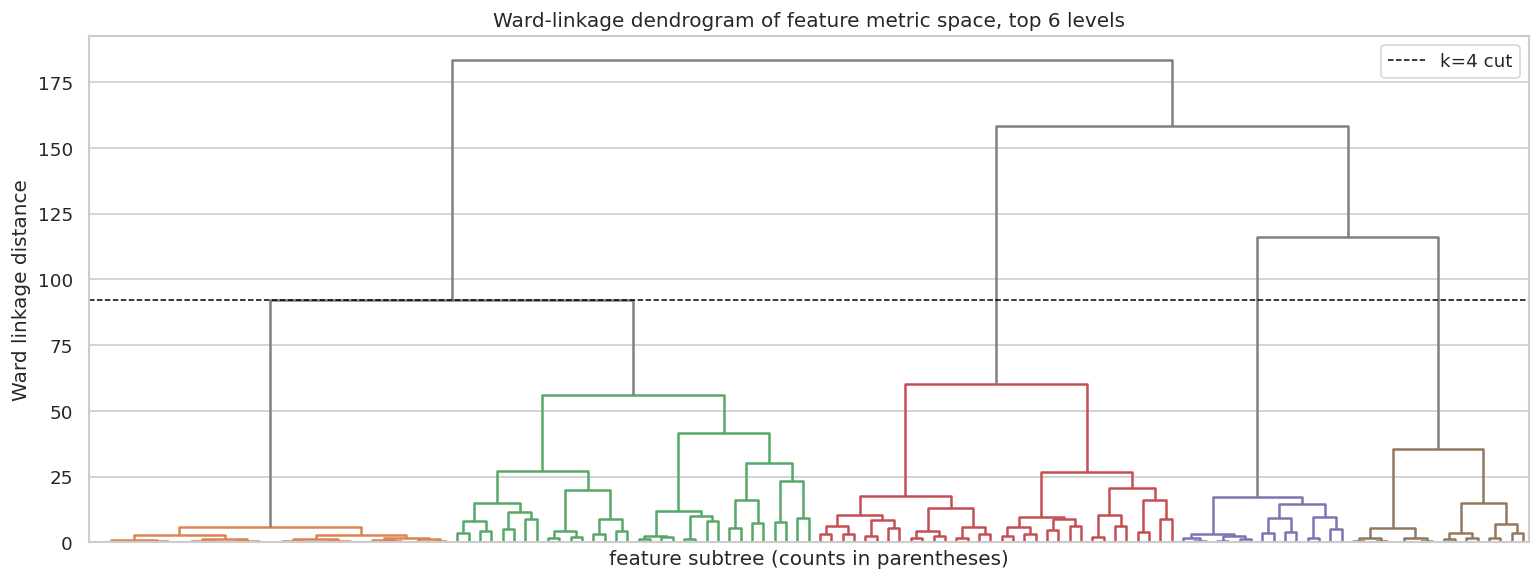

In [38]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

X_dedup_std = StandardScaler().fit_transform(dedup[METRIC_COLUMNS])
linkage_matrix = linkage(X_dedup_std, method="ward")

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=6,
    leaf_rotation=0,
    leaf_font_size=8,
    show_leaf_counts=True,
    no_labels=True,
    color_threshold=linkage_matrix[-4, 2],
    above_threshold_color="gray",
    ax=ax,
)
ax.axhline(linkage_matrix[-4, 2], color="black", linestyle="--", linewidth=0.9, label="k=4 cut")
ax.set_title("Ward-linkage dendrogram of feature metric space, top 6 levels")
ax.set_xlabel("feature subtree (counts in parentheses)")
ax.set_ylabel("Ward linkage distance")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

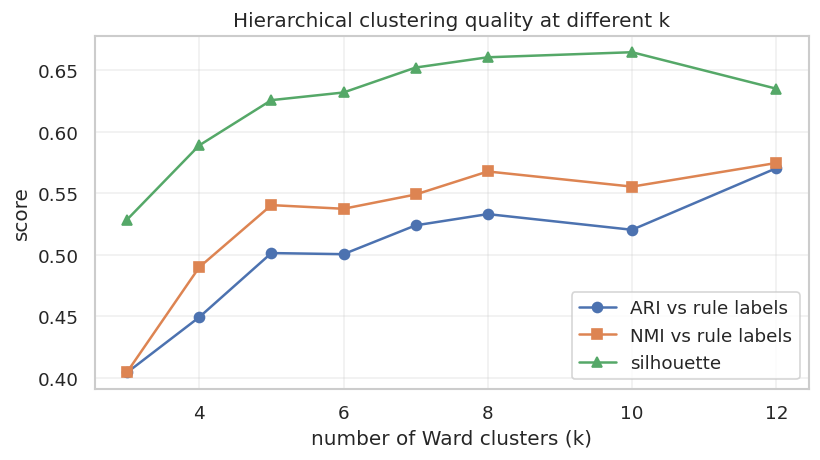

,k,ARI,NMI,silhouette
0,3,0.404422,0.404772,0.528677
1,4,0.449343,0.489934,0.589002
2,5,0.501470,0.540442,0.625747
3,6,0.500576,0.537470,0.631965
4,7,0.524000,0.549070,0.652248
5,8,0.533133,0.567778,0.660580
6,10,0.520386,0.555471,0.664698
7,12,0.570457,0.574686,0.635044


In [39]:
def hierarchical_partition(k):
    return fcluster(linkage_matrix, t=k, criterion="maxclust")

partitions_to_show = [4, 6, 8]

ward_summary = []
for k in [3, 4, 5, 6, 7, 8, 10, 12]:
    labels = hierarchical_partition(k)
    ward_summary.append({
        "k": k,
        "ARI": adjusted_rand_score(dedup["class"], labels),
        "NMI": normalized_mutual_info_score(dedup["class"], labels),
        "silhouette": silhouette_score(X_dedup_std, labels),
    })
ward_summary = pd.DataFrame(ward_summary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ward_summary["k"], ward_summary["ARI"], marker="o", label="ARI vs rule labels")
ax.plot(ward_summary["k"], ward_summary["NMI"], marker="s", label="NMI vs rule labels")
ax.plot(ward_summary["k"], ward_summary["silhouette"], marker="^", label="silhouette")
ax.set_xlabel("number of Ward clusters (k)")
ax.set_ylabel("score")
ax.set_title("Hierarchical clustering quality at different k")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

ward_summary

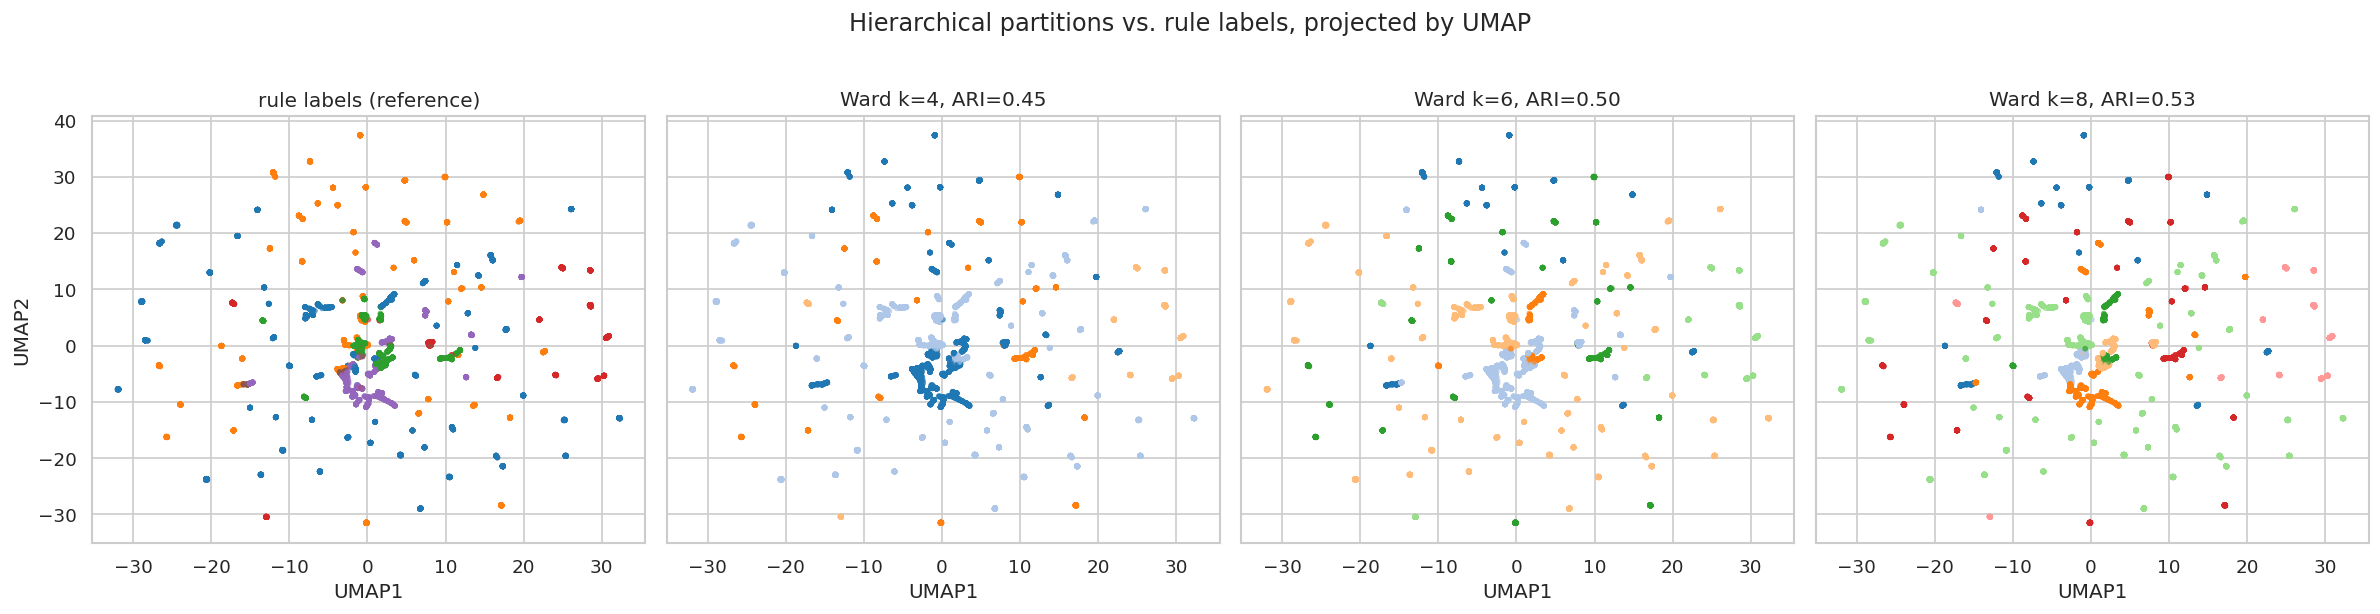

In [40]:
fig, axes = plt.subplots(1, len(partitions_to_show) + 1, figsize=(5 * (len(partitions_to_show) + 1), 5), sharex=True, sharey=True)

dedup_view2 = dedup.copy()
dedup_view2["UMAP1"] = umap_xy[:, 0]
dedup_view2["UMAP2"] = umap_xy[:, 1]

sns.scatterplot(
    data=dedup_view2,
    x="UMAP1", y="UMAP2",
    hue="class",
    hue_order=[c for c in CLASS_ORDER if c in dedup_view2["class"].unique()],
    palette=PALETTE,
    s=12, alpha=0.7, linewidth=0,
    ax=axes[0], legend=False,
)
axes[0].set_title("rule labels (reference)")

for ax, k in zip(axes[1:], partitions_to_show):
    labels = hierarchical_partition(k)
    sub_view = dedup_view2.copy()
    sub_view["ward"] = labels
    palette_k = sns.color_palette("tab20", n_colors=k)
    sns.scatterplot(
        data=sub_view,
        x="UMAP1", y="UMAP2",
        hue="ward",
        palette=palette_k,
        s=12, alpha=0.7, linewidth=0,
        ax=ax, legend=False,
    )
    ari = adjusted_rand_score(dedup["class"], labels)
    ax.set_title(f"Ward k={k}, ARI={ari:.2f}")

fig.suptitle("Hierarchical partitions vs. rule labels, projected by UMAP", y=1.02)
fig.tight_layout()
plt.show()

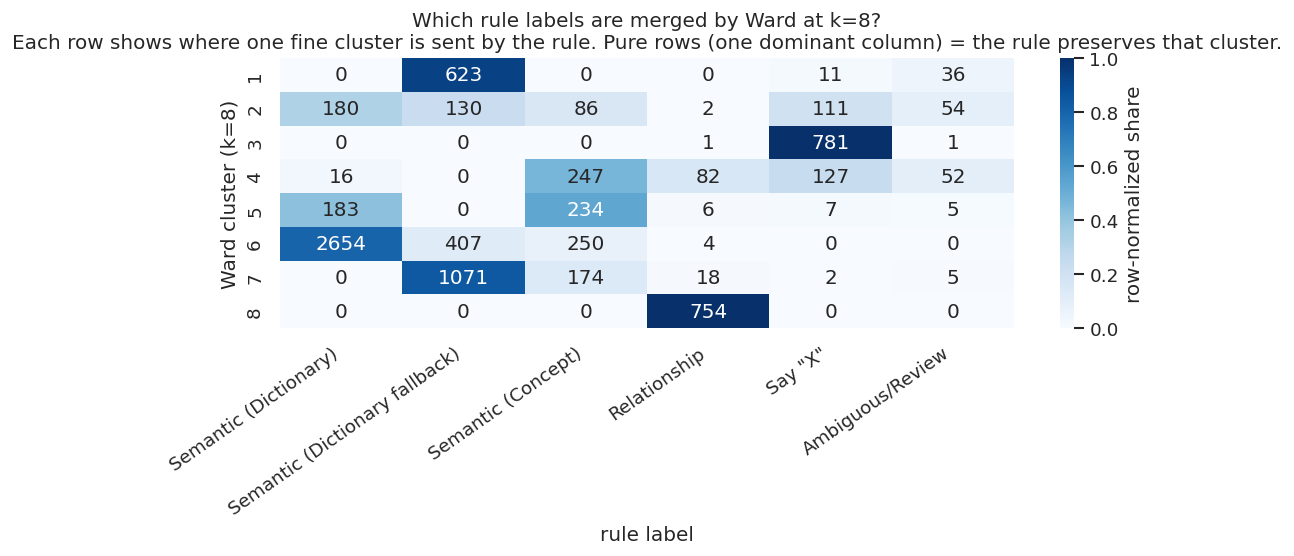

In [41]:
k_for_contingency = 8
ward_labels_8 = hierarchical_partition(k_for_contingency)

contingency = pd.crosstab(
    pd.Series(ward_labels_8, name=f"ward_k{k_for_contingency}"),
    dedup["class"].astype(str),
).reindex(columns=[c for c in CLASS_ORDER if c in dedup["class"].unique()], fill_value=0)
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, max(4, k_for_contingency * 0.6)))
sns.heatmap(
    contingency_norm,
    annot=contingency,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "row-normalized share"},
    ax=ax,
)
ax.set_xlabel("rule label")
ax.set_ylabel(f"Ward cluster (k={k_for_contingency})")
ax.set_title(
    f"Which rule labels are merged by Ward at k={k_for_contingency}?\n"
    "Each row shows where one fine cluster is sent by the rule. "
    "Pure rows (one dominant column) = the rule preserves that cluster."
)
plt.xticks(rotation=35, ha="right")
fig.tight_layout()
plt.show()

## Gaussian Mixture With BIC

Comparing ARI/silhouette across `k` by eye is informal. BIC (Bayesian Information Criterion) gives a principled answer to "how many components does the data prefer", penalizing extra components by the cost of fitting their parameters. The `k` minimizing BIC is the model with the best balance of fit and parsimony.

We fit GMMs over a range of `k` with two covariance shapes (`diag` and `full`) to check that the BIC-preferred `k` is robust to that choice. The right panel shows ARI vs the rule labels at each `k` so the BIC-preferred model can be compared to the user-set `k=4` directly.

BIC-minimizing k per covariance type:
covariance  k            BIC            AIC  ARI_vs_rules  silhouette
      diag 12 -292849.812827 -293938.795726      0.620139    0.558626
      full 10 -272336.607927 -274296.777144      0.631703    0.572522


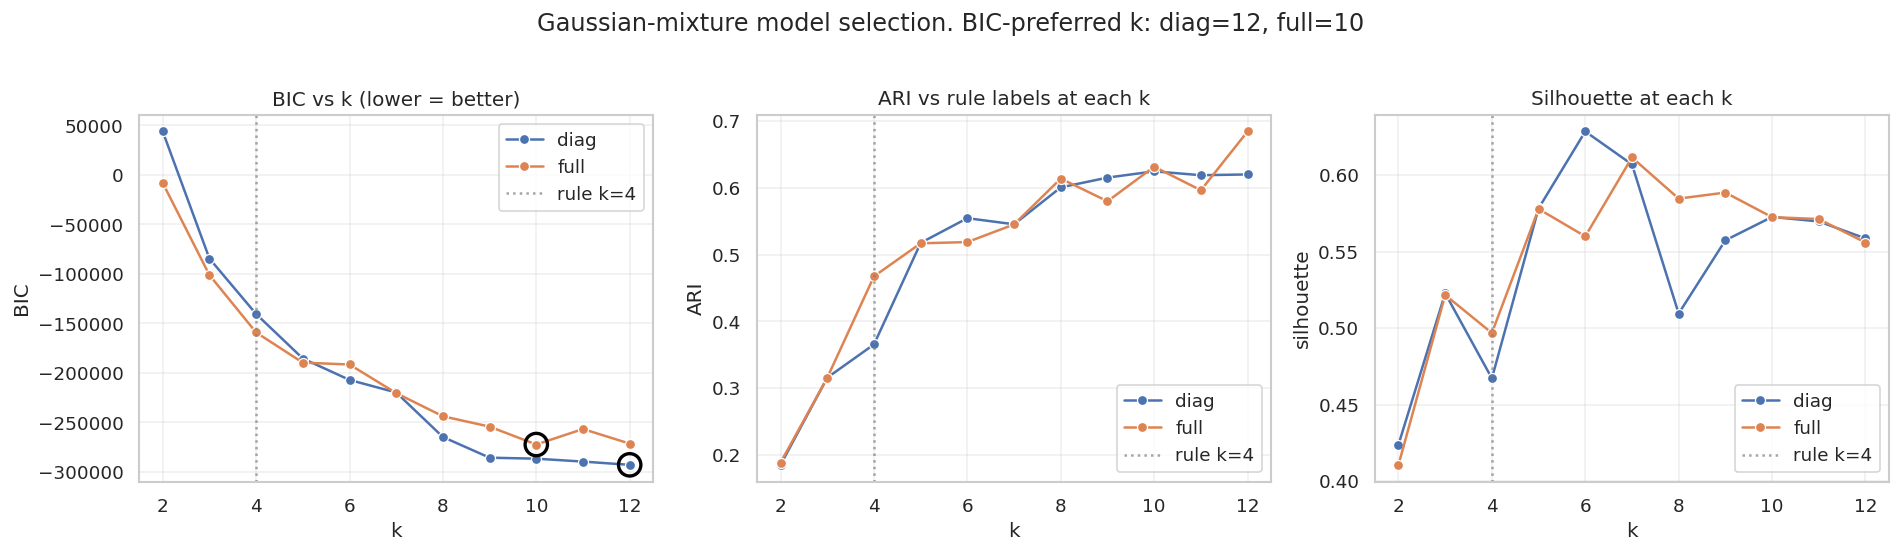

,covariance,k,BIC,AIC,ARI_vs_rules,NMI_vs_rules,silhouette
0,diag,2,43910.580917,43734.938514,0.185065,0.228747,0.423957
1,diag,3,-84454.307175,-84721.283627,0.315728,0.416317,0.522776
2,diag,4,-140473.952469,-140832.262971,0.365481,0.475094,0.467234
3,diag,5,-185442.221751,-185891.866303,0.517604,0.548191,0.578269
4,diag,6,-207068.130515,-207609.109117,0.554613,0.586081,0.628491
5,diag,7,-219776.113997,-220408.426648,0.545433,0.576915,0.606979
6,diag,8,-264727.840210,-265451.486910,0.600760,0.605776,0.509578
7,diag,9,-285632.747093,-286447.727843,0.615393,0.622614,0.557394
8,diag,10,-286634.694811,-287541.009610,0.624783,0.630183,0.572665
9,diag,11,-289568.282792,-290565.931641,0.618982,0.623043,0.569721


In [42]:
k_grid = list(range(2, 13))
gmm_results = []
for cov_type in ["diag", "full"]:
    for k in k_grid:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            random_state=0,
            n_init=3,
            max_iter=300,
        )
        gmm.fit(X_dedup_std)
        labels = gmm.predict(X_dedup_std)
        gmm_results.append({
            "covariance": cov_type,
            "k": k,
            "BIC": gmm.bic(X_dedup_std),
            "AIC": gmm.aic(X_dedup_std),
            "ARI_vs_rules": adjusted_rand_score(dedup["class"], labels),
            "NMI_vs_rules": normalized_mutual_info_score(dedup["class"], labels),
            "silhouette": silhouette_score(X_dedup_std, labels),
        })
gmm_df = pd.DataFrame(gmm_results)

best_per_cov = gmm_df.loc[gmm_df.groupby("covariance")["BIC"].idxmin()]
print("BIC-minimizing k per covariance type:")
print(best_per_cov[["covariance", "k", "BIC", "AIC", "ARI_vs_rules", "silhouette"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.lineplot(data=gmm_df, x="k", y="BIC", hue="covariance", marker="o", ax=axes[0])
for _, row in best_per_cov.iterrows():
    axes[0].scatter([row["k"]], [row["BIC"]], s=180, facecolors="none", edgecolors="black", linewidths=2, zorder=5)
axes[0].axvline(4, color="gray", linestyle=":", alpha=0.7, label="rule k=4")
axes[0].set_title("BIC vs k (lower = better)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.lineplot(data=gmm_df, x="k", y="ARI_vs_rules", hue="covariance", marker="o", ax=axes[1])
axes[1].axvline(4, color="gray", linestyle=":", alpha=0.7, label="rule k=4")
axes[1].set_title("ARI vs rule labels at each k")
axes[1].set_ylabel("ARI")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

sns.lineplot(data=gmm_df, x="k", y="silhouette", hue="covariance", marker="o", ax=axes[2])
axes[2].axvline(4, color="gray", linestyle=":", alpha=0.7, label="rule k=4")
axes[2].set_title("Silhouette at each k")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    "Gaussian-mixture model selection. "
    f"BIC-preferred k: diag={int(best_per_cov[best_per_cov['covariance']=='diag']['k'].iat[0])}, "
    f"full={int(best_per_cov[best_per_cov['covariance']=='full']['k'].iat[0])}",
    y=1.02,
)
fig.tight_layout()
plt.show()

gmm_df

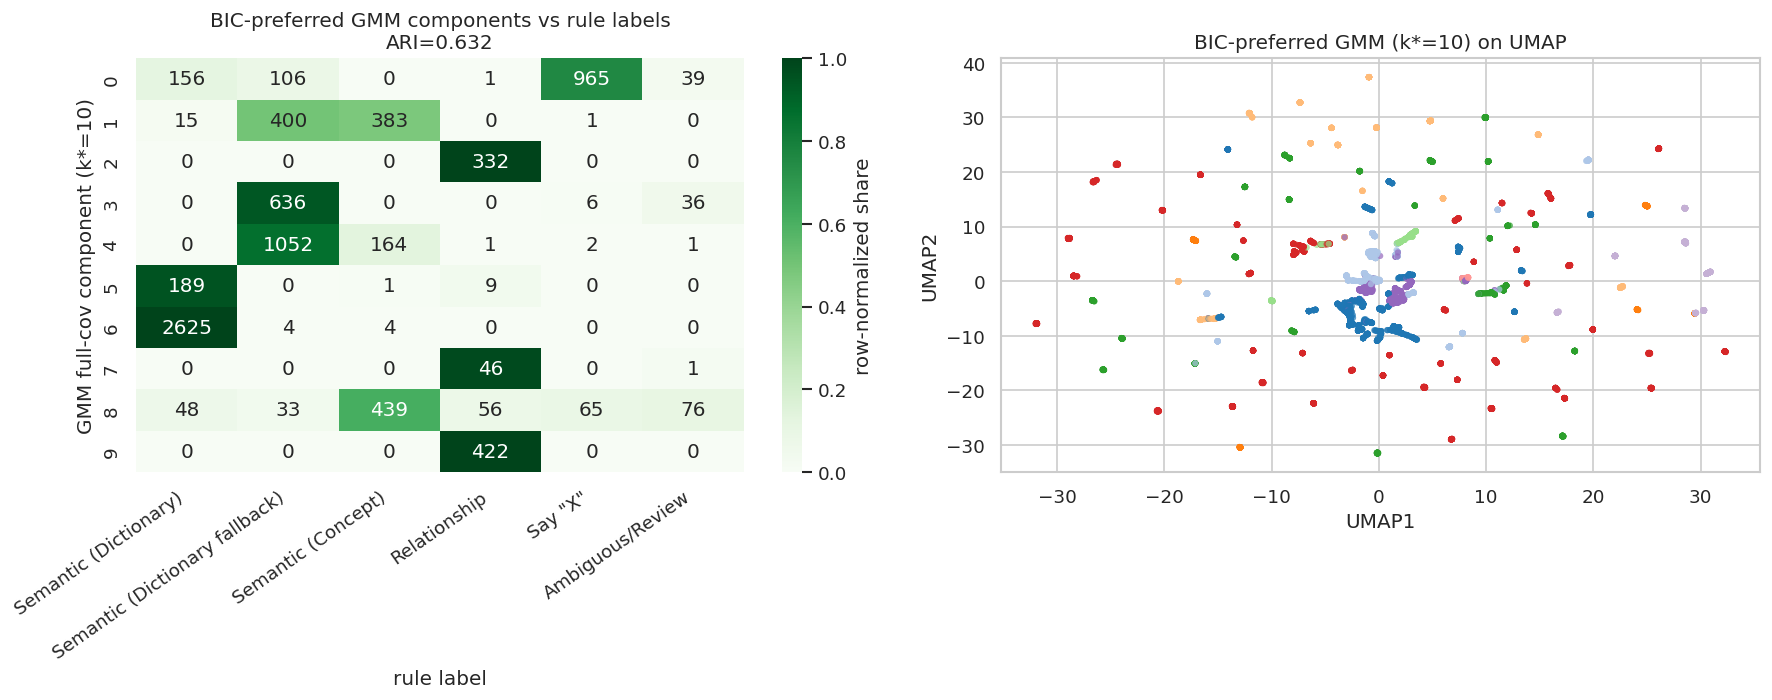

In [43]:
best_full = best_per_cov[best_per_cov["covariance"] == "full"].iloc[0]
k_star = int(best_full["k"])

gmm_star = GaussianMixture(
    n_components=k_star,
    covariance_type="full",
    random_state=0,
    n_init=5,
    max_iter=400,
).fit(X_dedup_std)
gmm_star_labels = gmm_star.predict(X_dedup_std)

contingency_star = pd.crosstab(
    pd.Series(gmm_star_labels, name=f"gmm_k{k_star}"),
    dedup["class"].astype(str),
).reindex(columns=[c for c in CLASS_ORDER if c in dedup["class"].unique()], fill_value=0)
contingency_star_norm = contingency_star.div(contingency_star.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, max(4.5, k_star * 0.6)))

sns.heatmap(
    contingency_star_norm,
    annot=contingency_star,
    fmt="d",
    cmap="Greens",
    cbar_kws={"label": "row-normalized share"},
    ax=axes[0],
)
axes[0].set_xlabel("rule label")
axes[0].set_ylabel(f"GMM full-cov component (k*={k_star})")
axes[0].set_title(f"BIC-preferred GMM components vs rule labels\nARI={adjusted_rand_score(dedup['class'], gmm_star_labels):.3f}")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")

dedup_view3 = dedup.copy()
dedup_view3["UMAP1"] = umap_xy[:, 0]
dedup_view3["UMAP2"] = umap_xy[:, 1]
dedup_view3["gmm_star"] = gmm_star_labels
palette_star = sns.color_palette("tab20", n_colors=k_star)
sns.scatterplot(
    data=dedup_view3,
    x="UMAP1", y="UMAP2",
    hue="gmm_star",
    palette=palette_star,
    s=14, alpha=0.7, linewidth=0,
    ax=axes[1], legend=False,
)
axes[1].set_title(f"BIC-preferred GMM (k*={k_star}) on UMAP")

fig.tight_layout()
plt.show()